In [22]:
import numpy as np
import matplotlib.pyplot as plt
import copy as cp
import scipy
from scipy.sparse import load_npz, dok_array
import math
import csv
from scipy.sparse import csr_matrix
import warnings
import pandas as pd
import sympy
from sympy import symbols, Eq, solve
from scipy.optimize import fsolve

## Defining universal values

In [23]:
THRES = 0            #start with THRES at 0 then determine from experimental results what this should be
NUM_REPLICATES = 4   #how many flasks there were in one experiment 
NUM_STRAINS = 95     #number of knock outs included in the pool
NUM_TIMEPOINTS = 4   #pre-seapreap, post-seaprep, and two passages
SAVED_VOLUME = 1500  #in uL 
T_FINAL = NUM_TIMEPOINTS - 1 #the final timepoint
TF_VOLUME = 50000    #total volume of the final timepoint
SPIKE = 89000        #amount of cells in the canavanine spike in

T0_TOTAL = np.array([3.4*(10**8), 3.9 *(10**8), 4.1*(10**8), 4.2 *(10**8)])    #for each replicate, how many cells were pre-selection
TCAN_TOTAL = np.array([4.6*(10**9), 3.3 *(10**9), 3.2*(10**9), 2.8 *(10**9)])  #for each replciate, how many cells were post-selection
TPASS_TOTAL = np.array([3.3*(10**9), 5.1*(10**9), 3.6*(10**9), 3.675*(10**9)]) #for each replicate, how many cells were in passage 1
TF_TOTAL = np.array([10**10, 1.25*(10**10), 6.5* (10**9), 5.9*(10**9)])        #for each replciate, how many cells were in passage 2

T0_MUT = np.array([5.3*(10**4), 2.7*(10**4), 5.4*(10**4), 4.5*(10**4)])   #for each replicate, how many mutants were pre-selection
TCAN_MUT = np.array([1.8*(10**9), 2.3*(10**9), 2.8*(10**9), 2.5*(10**9)]) #for each replicate, how many mutants were in passage 1
TPASS_MUT = np.array([4.1*(10**9), 4.88*(10**9), 3.9*(10**9),4.65*(10**9)])#for each replicate, how many mutants were in passage 2
TF_MUT = np.array([2.95*(10**9), 3.3*(10**9), 3.5*(10**9), 2.95*(10**9)])  #for each replicate, how many mutants were in passage 3



## Creating a list that contains the names of the strains in the order of barcode appearance


ex. YGR281W will correspond to the barcode at the 0th position in any matrix containg data for that barcode

In [24]:
f = open('Plate32_bcds_canavanine.csv','r')
names_bcds = f.readlines()[1:]
nm_bcds = [names_bcds[i].split(',') for i in range(NUM_STRAINS)]

names_bcds= [[row[0] , row[1].strip('\n')] for row in nm_bcds]
names_bcds

[['YGR281W', 'AGCTATTACCCAGTTCTACG'],
 ['YGR282C', 'CTCAACTGTGGTGAAGTACG'],
 ['YGR283C', 'GAATACGAGGTCACAGTACG'],
 ['YGR284C', 'GACGATAGCCTACCAGTACG'],
 ['YGR285C', 'ATATAGCGTGACAGAGTACG'],
 ['YGR286C', 'ACATCGGCTCTAATAGTACG'],
 ['YGR287C', 'CTAAGTGCGTCTAAGGTACG'],
 ['YGR288W', 'AAGAGCATCCTACAGGTACG'],
 ['YGR290W', 'ACATAGGTTTGAACGGTACG'],
 ['YHR021W-A', 'GCGCTTTAACGATTTGTACG'],
 ['YHR039C-B', 'ATCCAGACTCGCATATTACG'],
 ['YHR079C-B', 'GGTCCTCATACACTATTACG'],
 ['YIL009C-A', 'CGCCATGCTTAATACTTACG'],
 ['YIR017C', 'GCAGACTTGTGAATCTTACG'],
 ['YIR018W', 'GAAACGCTTGTGAAGTTACG'],
 ['YIR019C', 'GCCCAGGTAGTACAGTTACG'],
 ['YIR020C', 'TGATGCCACTGCACGTTACG'],
 ['YIR020W-B', 'CGGCCCTACTTTAATTTACG'],
 ['YIR021W', 'CATCGAGAGGCAGATTTACG'],
 ['YIR024C', 'TTATGAGACCGCTGCAACCG'],
 ['YIR025W', 'AATTAGCAGCCGCAGAACCG'],
 ['YIR026C', 'ACATACGAGCTTAGGAACCG'],
 ['YIR027C', 'TATACTAGCGGCTGGAACCG'],
 ['YIR028W', 'AACGCAGACGTAGGTAACCG'],
 ['YIR029W', 'AAGTCCCATTCATGTAACCG'],
 ['YIR031C', 'AATGTTAGCGACGCACACCG'],
 [

## 1.  PLOT THE READS THAT COME FROM EACH STRAIN

### Importing .npz files as numpy arrays

In [25]:
# Each replicate will be its own tensor of timepoints. ex REP1[0] will return counts for replicate 1 at the first timepoint
# For a given timepoint, there will be two matrices [bcds][counts]

REP0_names = ['1bcd.npz','2bcd.npz','3bcd.npz','4bcd.npz']
REP1_names = ['5bcd.npz','6bcd.npz','7bcd.npz','8bcd.npz']
REP2_names = ['D756bcd.npz','D757bcd.npz','D758bcd.npz','D759bcd.npz']
REP3_names = ['D768bcd.npz','D769bcd.npz','D770bcd.npz','D771bcd.npz']

REP0 = np.array([load_npz(name).toarray() for name in REP0_names])
REP1 = np.array([load_npz(name).toarray() for name in REP1_names])
REP2 = np.array([load_npz(name).toarray() for name in REP2_names])
REP3 = np.array([load_npz(name).toarray() for name in REP3_names])

choose_rep = [REP0, REP1, REP2, REP3]
want_bcds = 0
want_counts = 1

In [26]:
np.shape(REP0)

(4, 2, 95)

### For each replicate and timepoint, plot a histogram of all barcodes and their counts

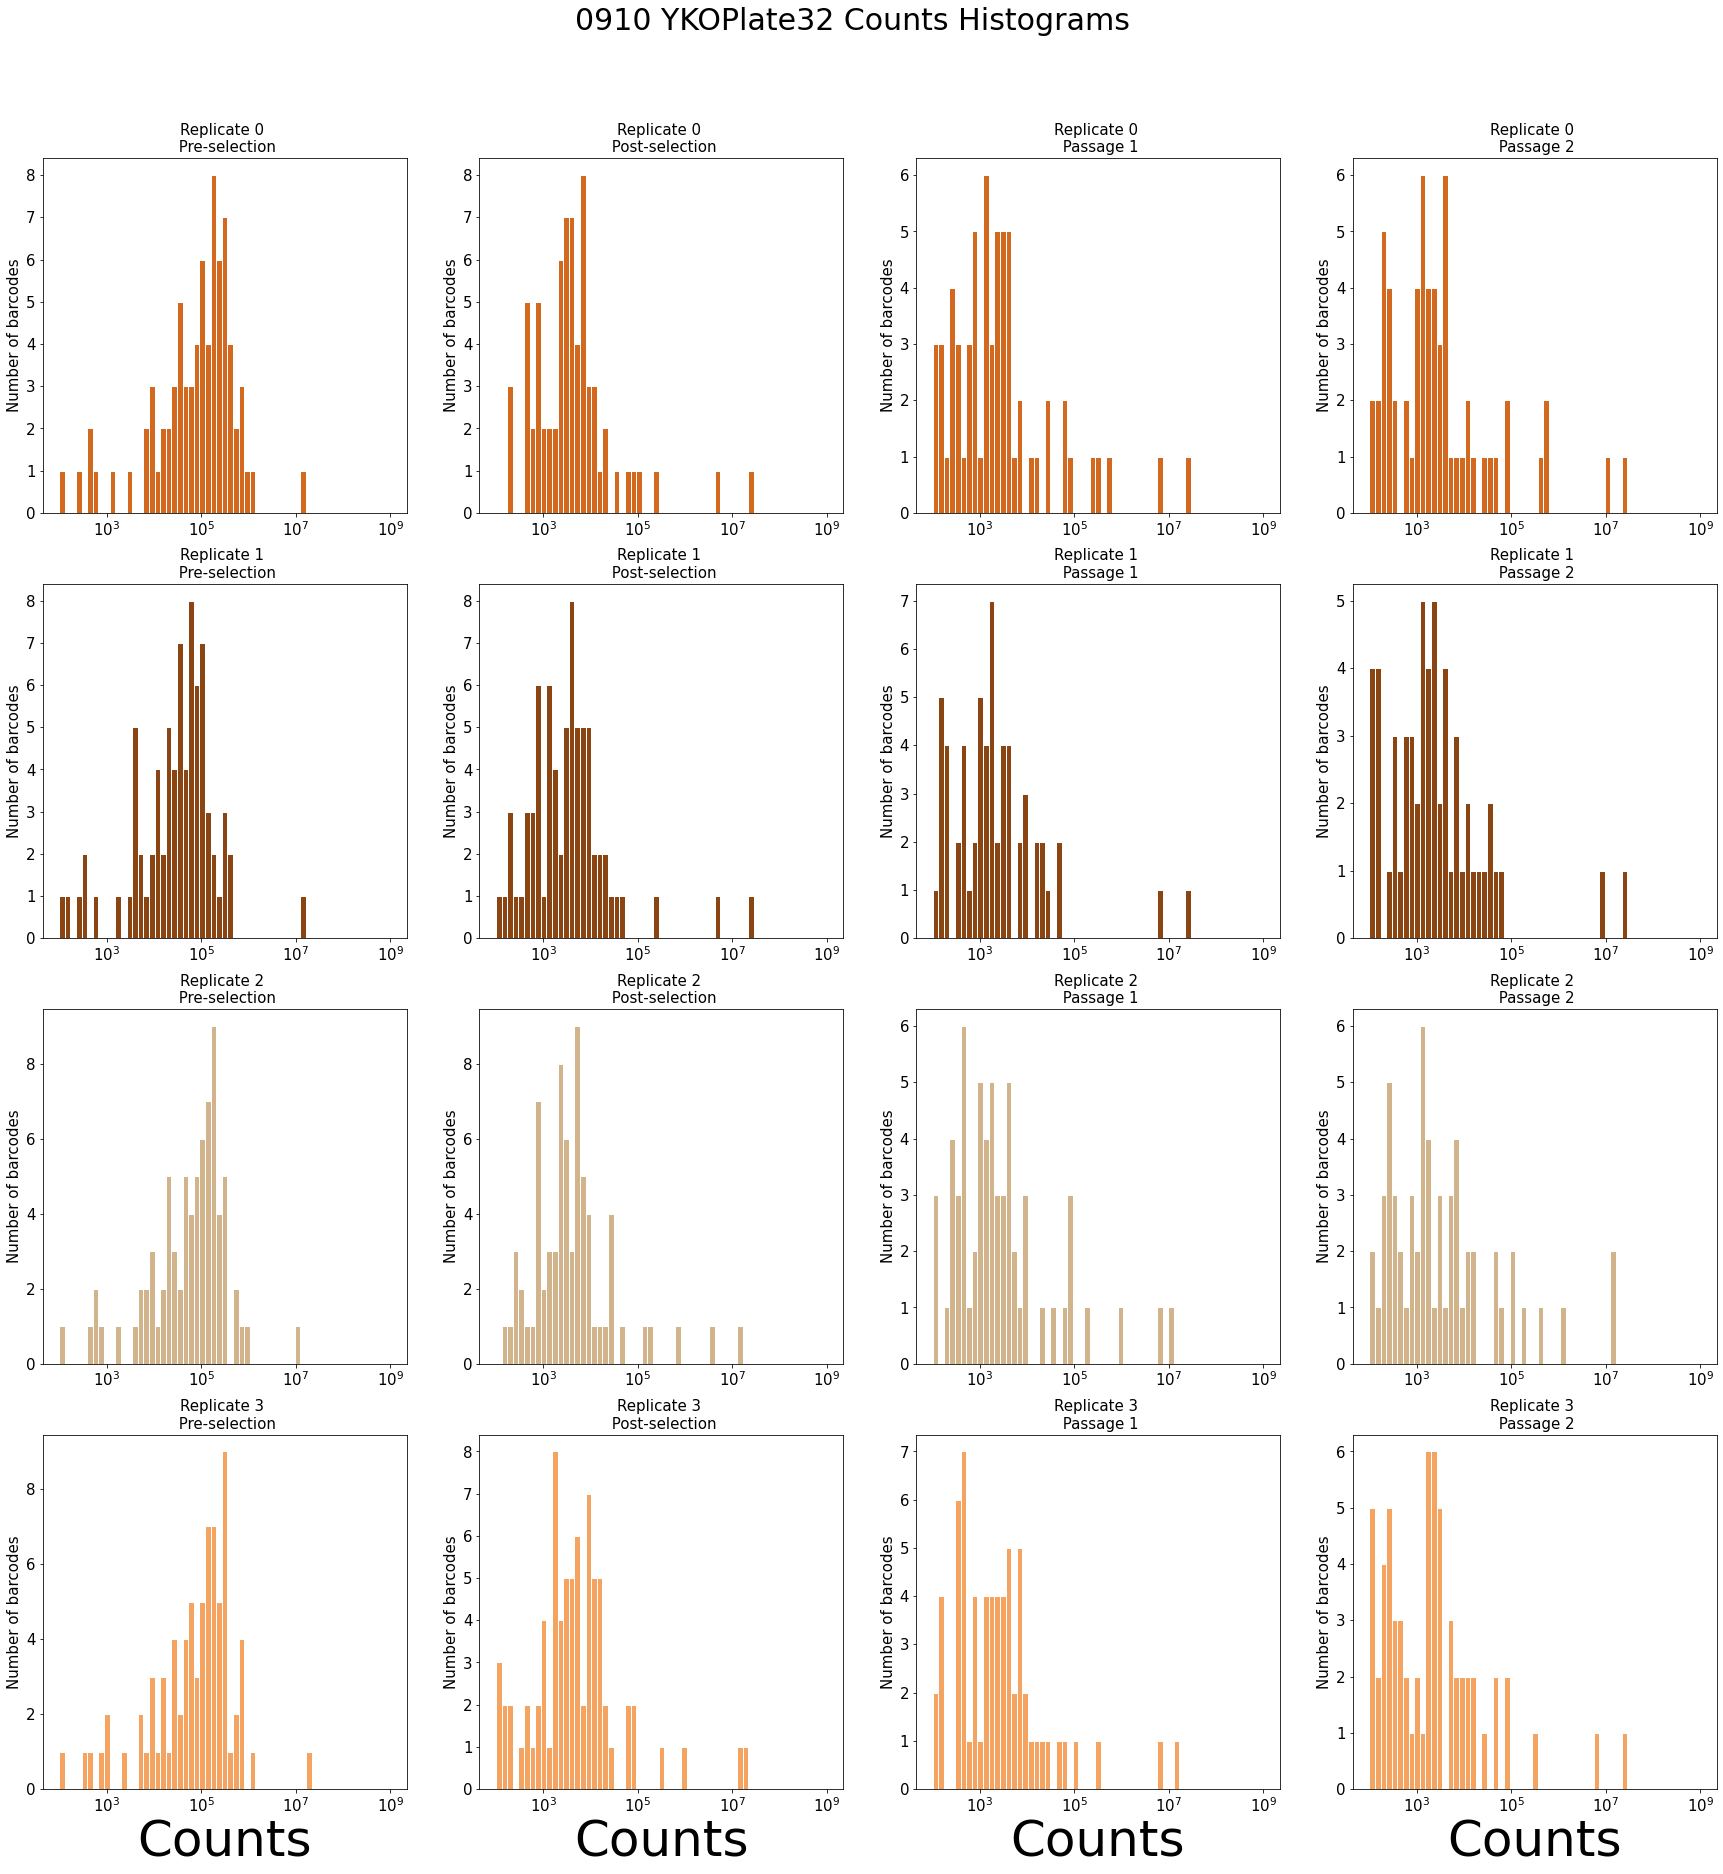

In [27]:
figure, ax = plt.subplots(4,4,figsize=(30, 30))
colors = ['Chocolate', 'Saddlebrown','Tan','Sandybrown']
times = ['Pre-selection', 'Post-selection', 'Passage 1', 'Passage 2']

for i in range(NUM_REPLICATES):
    for j in range(NUM_TIMEPOINTS):
        
        #choose_rep contains each REP matrix 
        # [i][j][1] --> [which replicate?][which timpoint][counts]
        ax[i,j].hist(choose_rep[i][j][1],bins = np.logspace(2,9,60),ec='white',color=colors[i])
        
        if i > 2:
            ax[i,j].set_xlabel('Counts', fontsize = 50)
        
        
        ax[i,j].set_ylabel('Number of barcodes', fontsize = 15)
        ax[i,j].set_title(f'Replicate {i} \n {times[j]}', fontsize = 15)
        ax[i,j].set_xscale("log")
        ax[i,j].tick_params(axis='both', which='major', labelsize=15)
        ax[i,j].tick_params(axis='both', which='minor', labelsize=8)

figure.suptitle("0910 YKOPlate32 Counts Histograms", fontsize=30, y = 0.95)        
figure.savefig("0910 YKOPlate32 Counts Histograms.pdf", format="pdf")

plt.show()

#### Notes 

1. There is one barcode that is consistently present across all barcode and replicates at 10^7 counts. My initial instinct is that this is the msh2 strain. It is the fastest mutator in this plate. However, that does not justify its abundance pre-selection. There is one very fast grower in the plate named YHR039C-B. Maybe this one is the culprit. It's position is 79. The culprit: ['YNR070W', 'ACGATAGCGGTACATCTCGG', 'G9']
2. There seems to be a leftward shift between the pre selection and post selection timepoints for all replicates which makes sense for experimental expectations of decrease in fitness, cell death, and the emergence of a few more fit species (i.e. mutators)
3. Replicate 2 differs from the others in that there doesnt seem to be an appearnce of a few barcodes that are in higher counts than the rest of the population. 

## Identifying the outliers in each plot

In [28]:
outlier_threshold = np.array([[10**7, 2*(10**6), 10**5, 10**5],[10**5,10**5,3*(10**6),3*(10**6)],[8*10**6, 2*10**5, 2*10**5, 2*10**5],[10**6, 2*(10**5), 10**5, 10**5]]) 


for k in range(NUM_REPLICATES):
    print(f'REP{k} Outliers')
    out_loc = [np.where(choose_rep[k][i,1] > outlier_threshold[k,i]) for i in range(NUM_TIMEPOINTS)]
    outliers = [[names_bcds[i][0] for i in out_loc[j][0]] for j in range(NUM_REPLICATES)]

    print(f'{outliers} \n\n')
    
    

REP0 Outliers
[['YNR070W'], ['YIR033W', 'YEL063C'], ['YGR288W', 'YIR033W', 'YIR037W', 'YMR082C', 'YEL063C'], ['YGR288W', 'YIR033W', 'YIR037W', 'YMR082C', 'YEL063C']] 


REP1 Outliers
[['YGR284C', 'YHR021W-A', 'YHR079C-B', 'YIR019C', 'YIR024C', 'YIR025W', 'YIR028W', 'YIR029W', 'YIR031C', 'YIR042C', 'YMR070W', 'YMR082C', 'YMR085W', 'YMR086C-A', 'YMR088C', 'YNR070W', 'YOL088C', 'YOL092W'], ['YIR033W', 'YNR070W', 'YEL063C'], ['YIR033W', 'YEL063C'], ['YIR033W', 'YEL063C']] 


REP2 Outliers
[['YNR070W'], ['YIR033W', 'YMR080C', 'YEL063C'], ['YIR033W', 'YMR080C', 'YEL063C'], ['YIR033W', 'YMR080C', 'YOL091W', 'YEL063C']] 


REP3 Outliers
[['YMR082C', 'YNR070W'], ['YIR033W', 'YMR086W', 'YNR070W', 'YEL063C'], ['YIR033W', 'YMR086W', 'YNR070W', 'YEL063C'], ['YIR033W', 'YMR086W', 'YEL063C']] 




#### Notes on YNR070W

"Transporter of the ATP-binding cassette (ABC) family; role in plasma membrane sterol incorporation; implicated in pleiotropic drug resistance; provides resistance to ethanol stress and contributes to a decreased intracellular accumulation of ethanol
Name Description: Pleiotropic Drug Resistance" - From SGD

It makes sense that a drug restance and stress response gene would be present in abundant in post-selection, but abundance in preselecion still is a mystery to me. 

## 2.  AT EACH TIMEPOINT FOR EACH EXPERIMENT, PLOT BARCODE FREQUECIES 

In [29]:
REP0_freq = np.array([REP0[:,1][i]/np.sum(REP0[:,1][i]) for i in range(NUM_TIMEPOINTS)])
REP1_freq = np.array([REP1[:,1][i]/np.sum(REP1[:,1][i]) for i in range(NUM_TIMEPOINTS)])
REP2_freq = np.array([REP2[:,1][i]/np.sum(REP2[:,1][i]) for i in range(NUM_TIMEPOINTS)])
REP3_freq = np.array([REP3[:,1][i]/np.sum(REP3[:,1][i]) for i in range(NUM_TIMEPOINTS)])


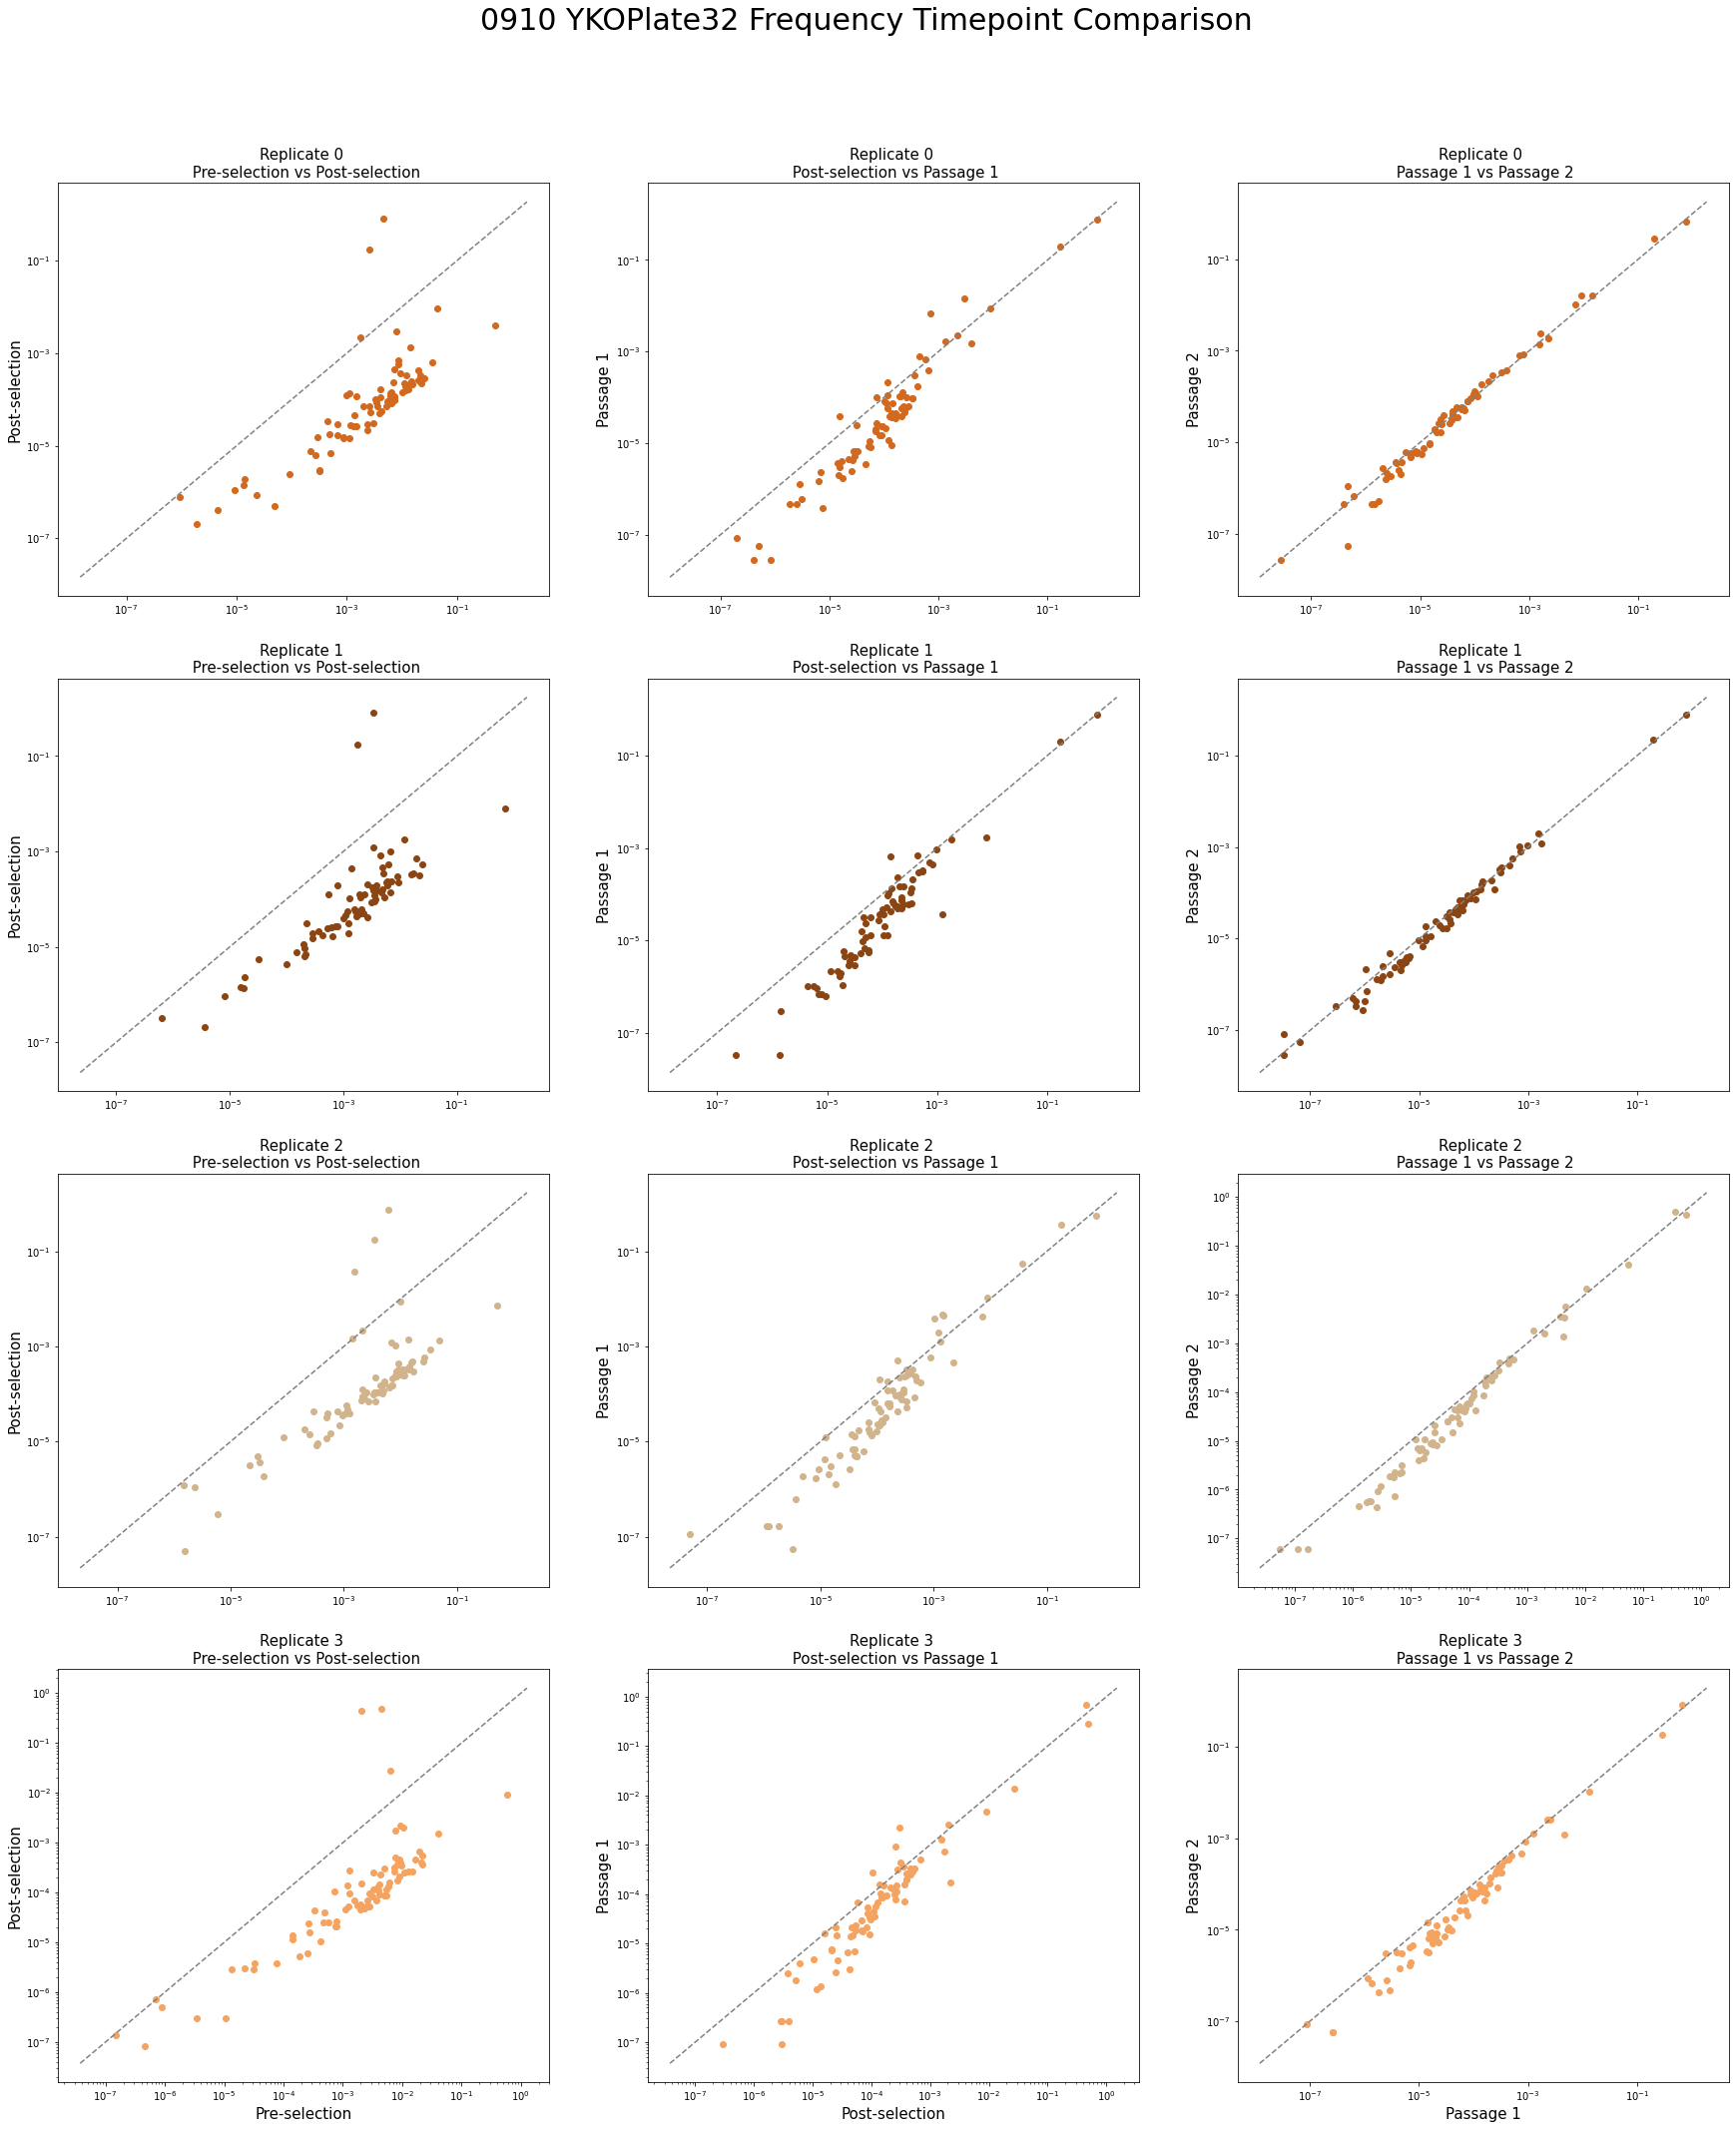

In [30]:

figure, ax = plt.subplots(4,3,figsize=(30, 35))

choose_rep_fq = [REP0_freq, REP1_freq, REP2_freq, REP3_freq]

for i in range(NUM_REPLICATES):
    for j in range(NUM_TIMEPOINTS - 1):
        
        #for each replicate, plot frequencies at a timepoint vs its next timepoint
        ax[i,j].scatter(choose_rep_fq[i][j], choose_rep_fq[i][j+1], color=colors[i])
        
        
        if i > 2:
            ax[i,j].set_xlabel(f'{times[j]}', fontsize = 15)
        
        ax[i,j].set_ylabel(f'{times[j+1]}', fontsize = 15)
        ax[i,j].set_title(f'Replicate {i} \n {times[j]} vs {times[j+1]}', fontsize = 15)
        #ax[i,j].set_xlim(-0.025,0.1)
        #ax[i,j].set_ylim(-0.025,0.1)
        
        ax[i,j].set_yscale('log')
        ax[i,j].set_xscale('log')
        
        #making a diagonal line to show perfect linear relationship
        xmin, xmax = ax[i,j].get_xlim()
        ymin, ymax = ax[i,j].get_ylim()
        limits = [min(xmin, ymin), max(xmax, ymax)]  # Ensure the dashed line covers all values

        # plotting the diagonal
        ax[i,j].plot(limits, limits, linestyle="--", color="gray", label="Diagonal y=x")



figure.suptitle("0910 YKOPlate32 Frequency Timepoint Comparison", fontsize=30, y = 0.95)
figure.savefig("0910 YKOPlate32 Frequency Timepoint Comparison.pdf", format="pdf")

plt.show()

Note: Since we did not see perfect covergence at the last two timepoints, it may be beneficial to add another passaging step for future experiments.

### How have the frequencies of msh1, can1, and an approx. wildtype changed over time?

Can1 = YEL063C, 'TATCTAGTCGCATGTGATGG', its integer barcode


WT/BGL2 = YGR282C, 'CTCAACTGTGGTGAAGTACG', A2


msh1 = YOL090W, 'TTACACTCTCTAGCATTCGG', H9, its integer barcode


In [31]:
def encodeATGC(bcdStr):
    return int(bcdStr.replace("A","0").replace("T","1").replace("G","2").replace("C","3"), 4)
def encodeATGC_revComp(bcdStr):
    bcdStr = bcdStr[::-1]
    return int(bcdStr.replace("A","1").replace("T","0").replace("G","3").replace("C","2"), 4)


In [32]:
# encode the strains
can1 = encodeATGC('TATCTAGTCGCATGTGATGG')
bgl2 = encodeATGC('CTCAACTGTGGTGAAGTACG')
msh2 = encodeATGC('TTACACTCTCTAGCATTCGG')

bgl2_location = np.where(REP0[0][0] == bgl2)
msh2_location = np.where(REP0[0][0] == msh2)
can1_location = np.where(REP0[2][0] == can1)

print(bgl2_location)
print(msh2_location)
print(can1_location)


(array([1]),)
(array([90]),)
(array([94]),)


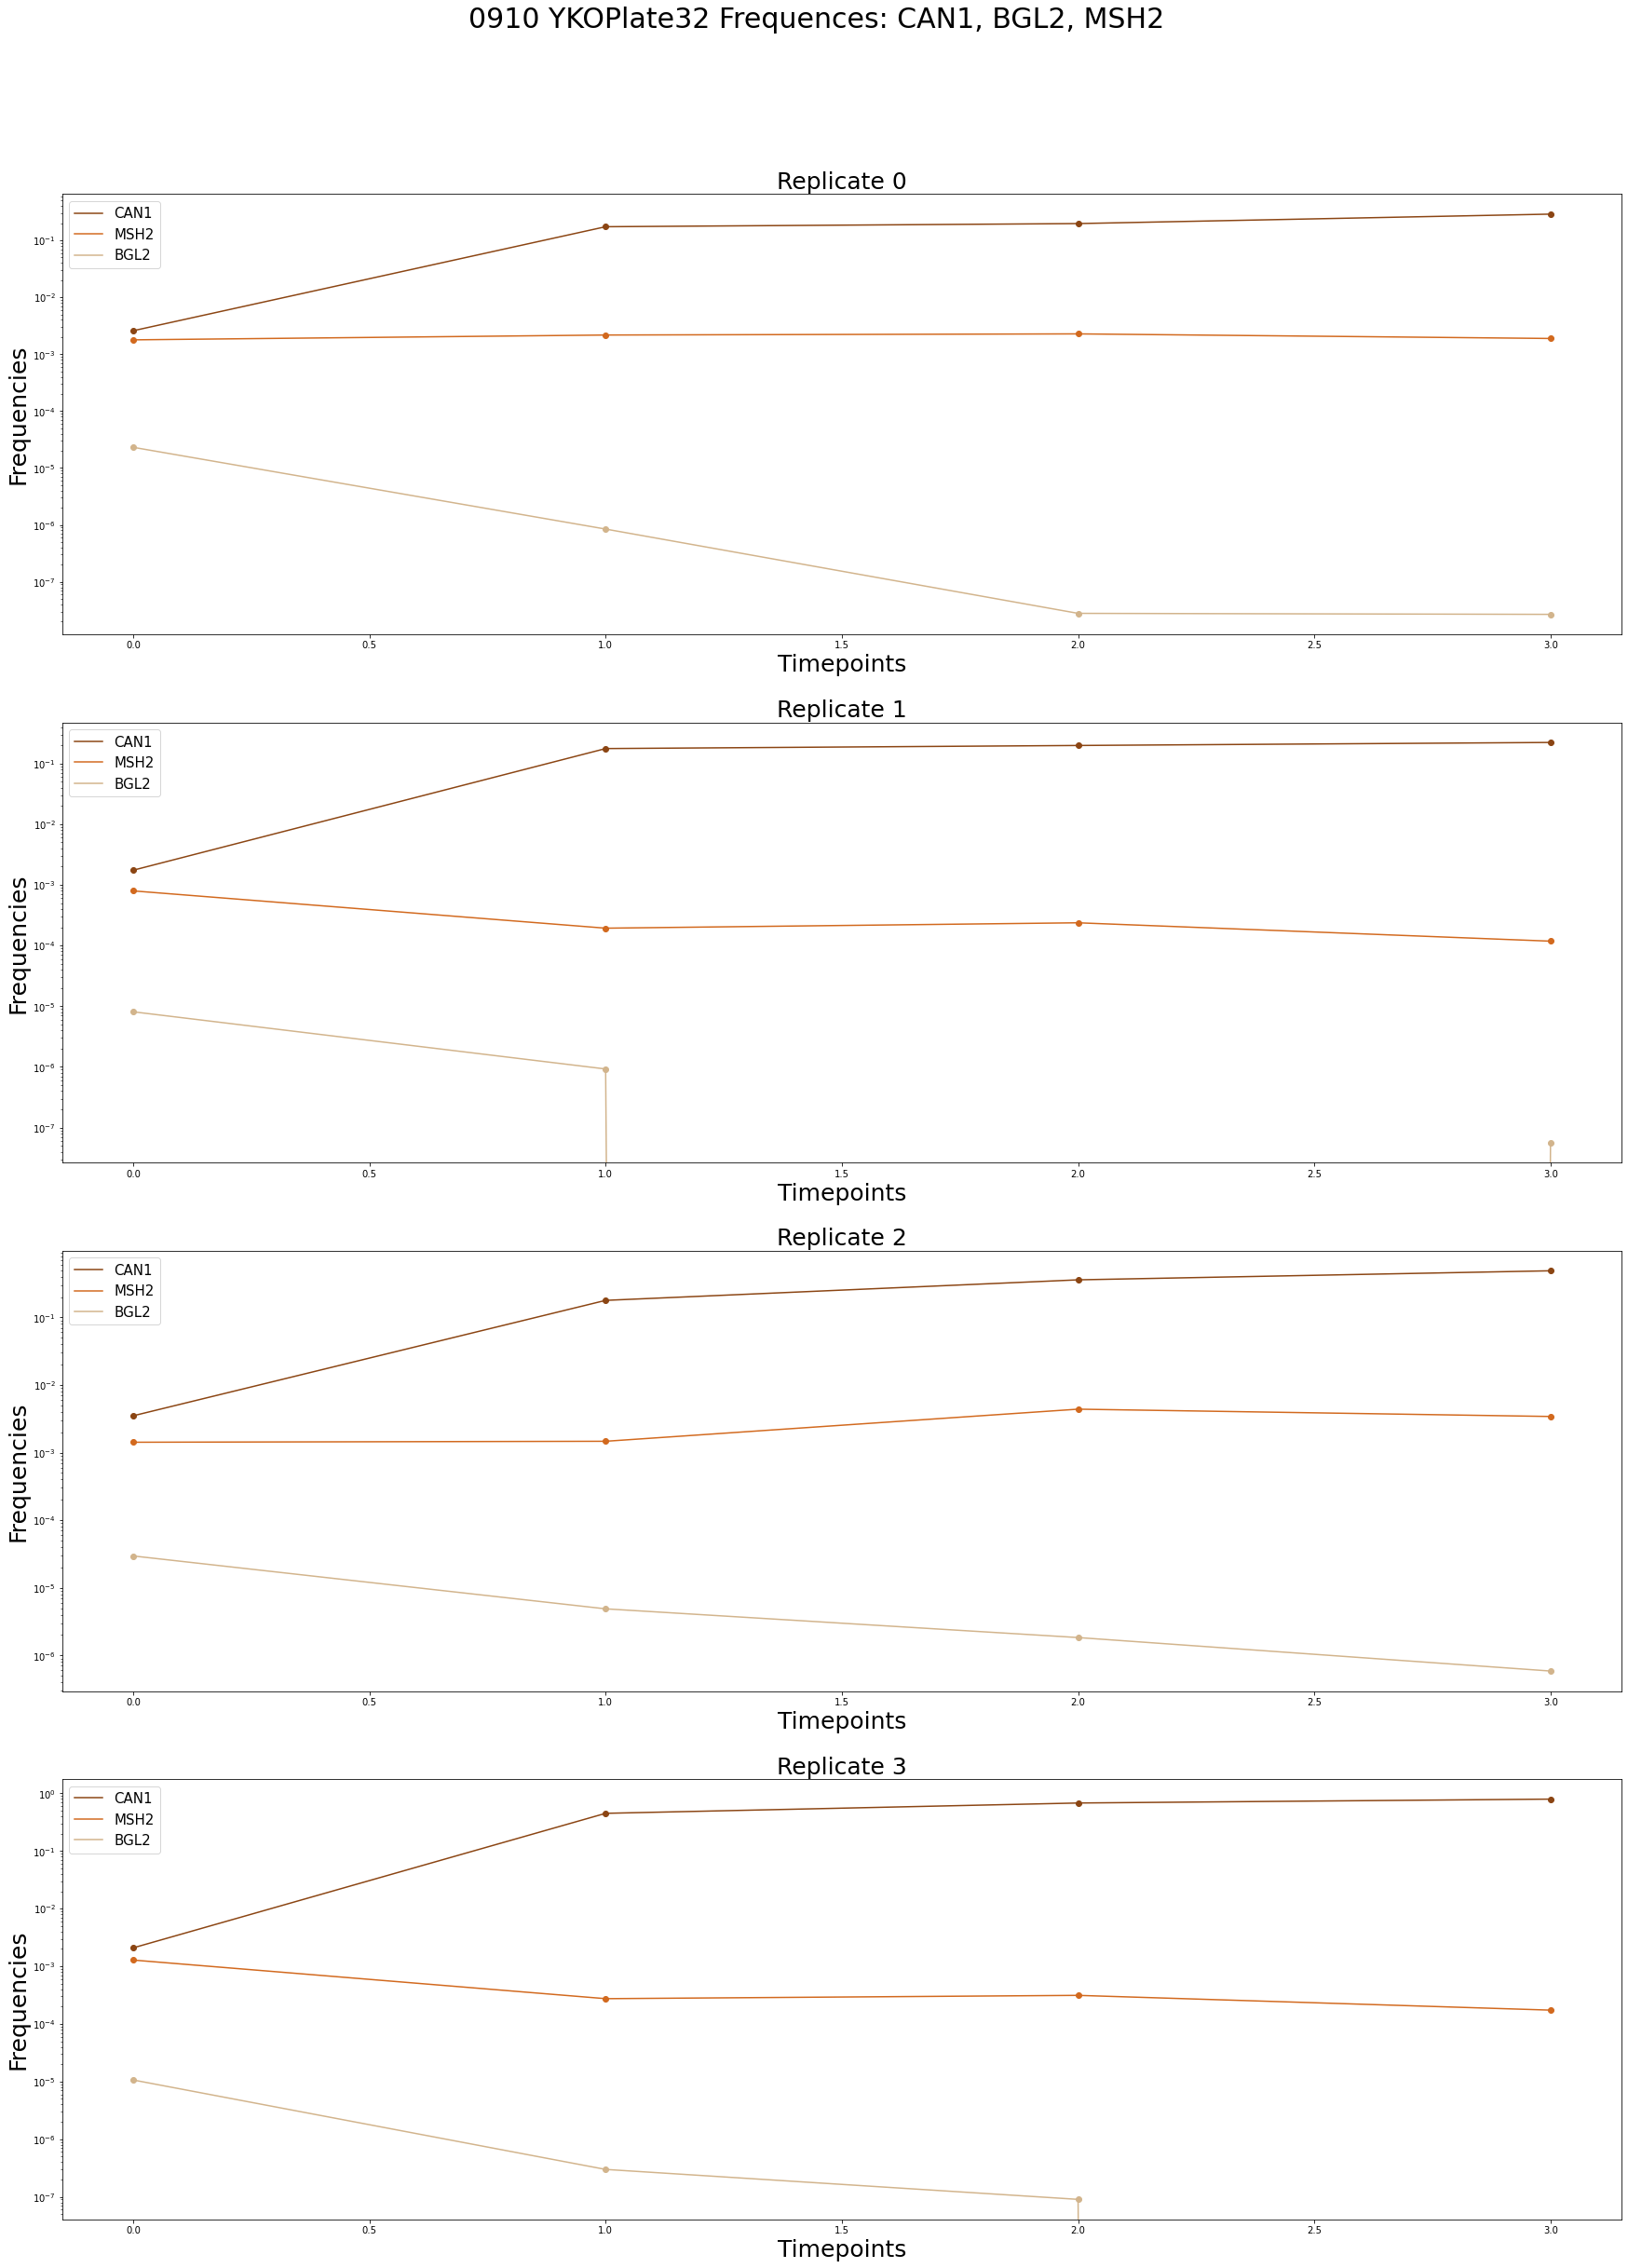

In [33]:

figure, ax = plt.subplots(4,1,figsize=(30, 40))

for i in range(NUM_REPLICATES):
    
    #use the frequency matrix to return freq at each timepoint for these three strains
    can1_freq = [fq.flatten()[can1_location] for fq in choose_rep_fq[i]]
    msh2_freq = [fq.flatten()[msh2_location] for fq in choose_rep_fq[i]]
    bgl2_freq = [fq.flatten()[bgl2_location] for fq in choose_rep_fq[i]]
    
    #plotting points to make timepoints clear
    ax[i].scatter(np.arange(NUM_TIMEPOINTS), can1_freq, color = 'Saddlebrown')
    ax[i].scatter(np.arange(NUM_TIMEPOINTS), msh2_freq, color = 'Chocolate')
    ax[i].scatter(np.arange(NUM_TIMEPOINTS), bgl2_freq, color = 'Tan')
    
    #plotting line to make change over time clear
    ax[i].plot(np.arange(NUM_TIMEPOINTS),can1_freq, color = 'Saddlebrown', label = 'CAN1')
    ax[i].plot(np.arange(NUM_TIMEPOINTS),msh2_freq, color = 'Chocolate', label = 'MSH2')
    ax[i].plot(np.arange(NUM_TIMEPOINTS),bgl2_freq, color = 'Tan', label = 'BGL2')
    
    ax[i].set_title(f'Replicate {i}', fontsize = 25)
    ax[i].set_xlabel("Timepoints", fontsize = 25)
    ax[i].set_ylabel("Frequencies", fontsize = 25)
    ax[i].set_yscale('log')
    ax[i].legend(fontsize = 15)
    
figure.suptitle("0910 YKOPlate32 Frequences: CAN1, BGL2, MSH2", fontsize=30, y = 0.95)
figure.savefig("0910 YKOPlate32  Frequencies_CAN1_BGL1_MSH2.pdf", format="pdf")

plt.show()

In [34]:
### How have the frequencies of all strains changed overtime

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles wi

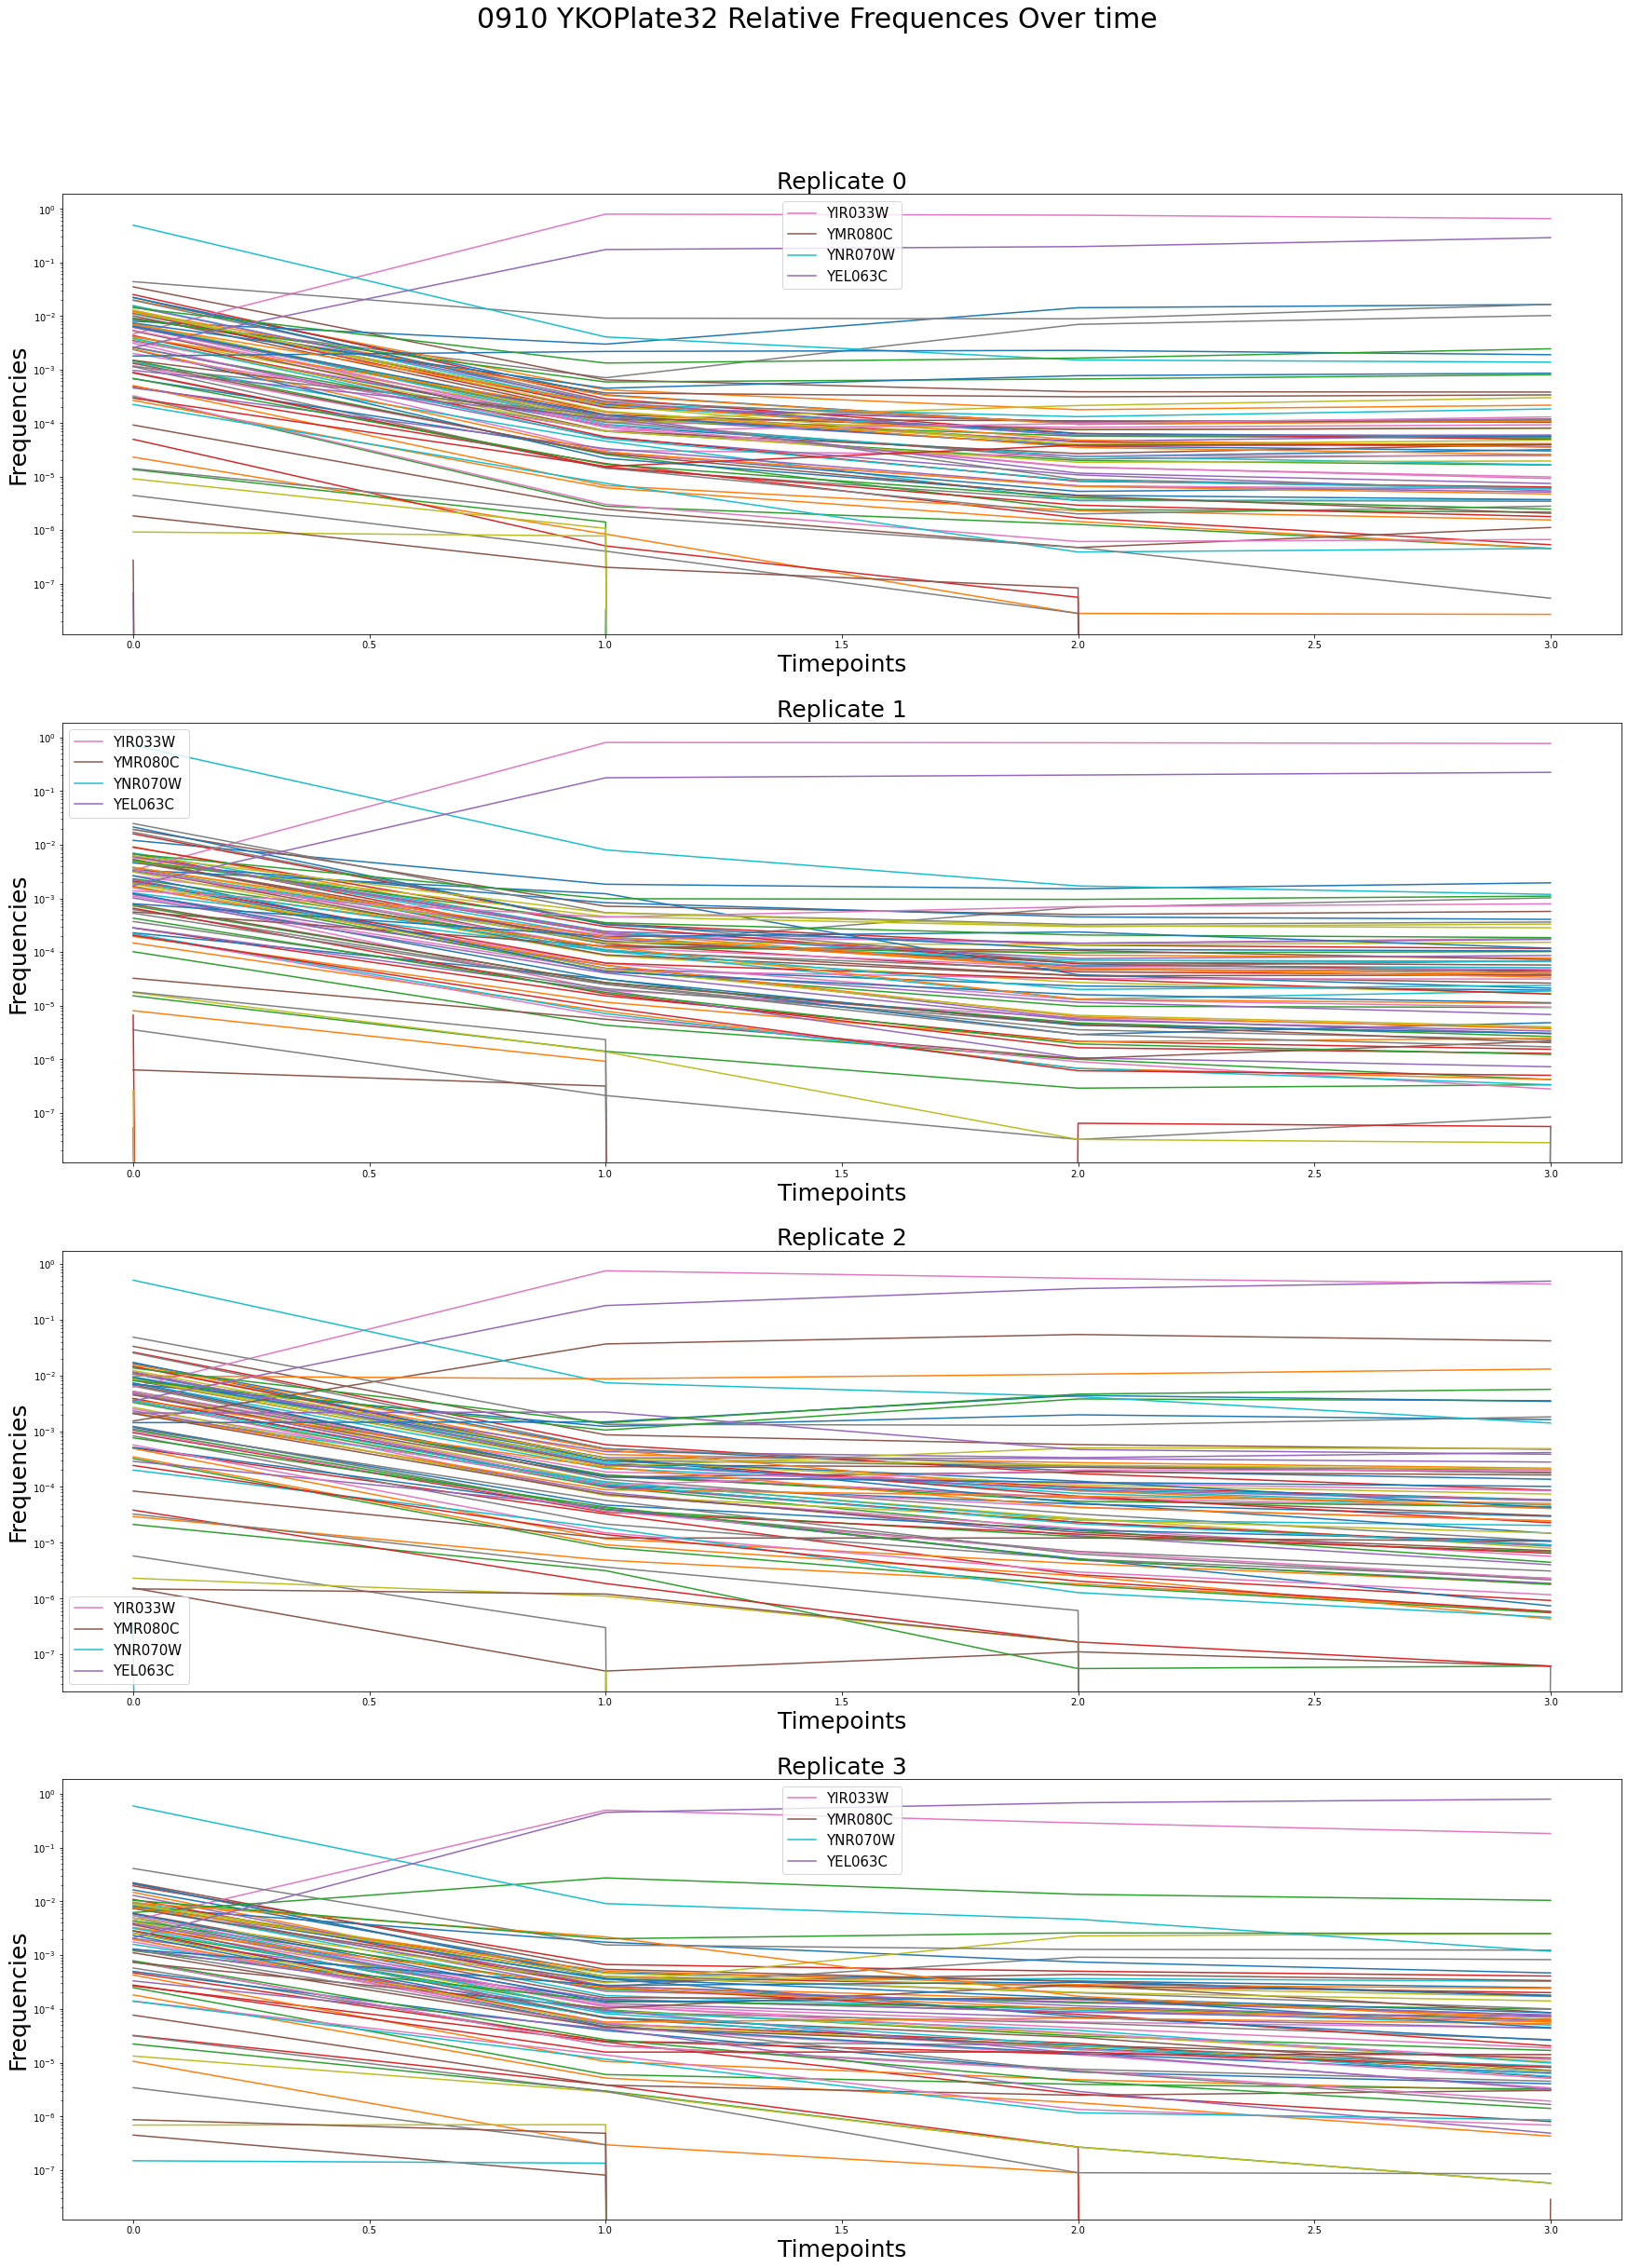

In [35]:
#track all frequencies

figure, ax = plt.subplots(NUM_REPLICATES,1,figsize=(30, 40))

#chose these entries after seeing the plots. These strains rise above the clade
entries_to_label = {26, 79, 94, 65}

for i in range(NUM_REPLICATES):
    for j in range(len(names_bcds)):
        
        label = f"{names_bcds[j][0]}" if j in entries_to_label else None
        
        ax[i].plot(range(NUM_TIMEPOINTS), [fq.flatten()[j] for fq in choose_rep_fq[i]], label = label)
        
        ax[i].legend(fontsize = 15)
        ax[i].set_xlabel("Timepoints", fontsize = 25)
        ax[i].set_ylabel("Frequencies", fontsize = 25)
        ax[i].set_title(f'Replicate {i}', fontsize = 25)
        ax[i].set_yscale('log')


figure.suptitle("0910 YKOPlate32 Relative Frequences Over time", fontsize=30, y = 0.95)
figure.savefig("0910 YKOPlate32 Relative Frequencies Over Time.pdf", format="pdf")
plt.show()


### Noting interesting strains

In [36]:
#defining strains from location in names matrix
cool_strain1 = names_bcds[26]
cool_strain2 = names_bcds[79]
cool_strain3 = names_bcds[94]
print(cool_strain1) 
print("Lipid sensor of ER membrane that regulates OLE1 transcription\n")
print(cool_strain2)
print("Transporter of the ATP-binding cassette\n")
print(cool_strain3)
print("CAN1")

['YIR033W', 'TAAGAGAGGTTACGACACCG']
Lipid sensor of ER membrane that regulates OLE1 transcription

['YNR070W', 'ACGATAGCGGTACATCTCGG']
Transporter of the ATP-binding cassette

['YEL063C', 'TATCTAGTCGCATGTGATGG']
CAN1


cool_strain1: https://www.yeastgenome.org/locus/S000001472


cool_strain2: https://www.yeastgenome.org/locus/S000005353


## 3. Normalizing frequencies wrt Can1 



Method 1:
    Obtain frequences at the final time point. 
    Calculate # of mutant colonies for a bcd by evaluating (freq * total # of mutant colonies)


Method 2:
    Obtain # of mutant colonies/bcd by calculating (reads of bcd/reads for can1)* 89000
    


### Method 1

In [37]:

choose_rep_fq = np.array(choose_rep_fq) 

final_tp = choose_rep_fq[:,T_FINAL]  #array of all barcode frequencies at the final timepoint

#finding number of colonies for each barcode by multiplying frequencies at t_final by the total number of mutants 
# right after selection
num_colonies = np.array([final_tp[i]*TCAN_MUT[i] for i in range(NUM_REPLICATES)]).astype(int)

for j in range(NUM_REPLICATES):
    print(f'For rep {j}: {len(np.where(num_colonies[j] == 0)[0])} barcodes did not produce mutant colonies')



For rep 0: 21 barcodes did not produce mutant colonies
For rep 1: 17 barcodes did not produce mutant colonies
For rep 2: 18 barcodes did not produce mutant colonies
For rep 3: 19 barcodes did not produce mutant colonies


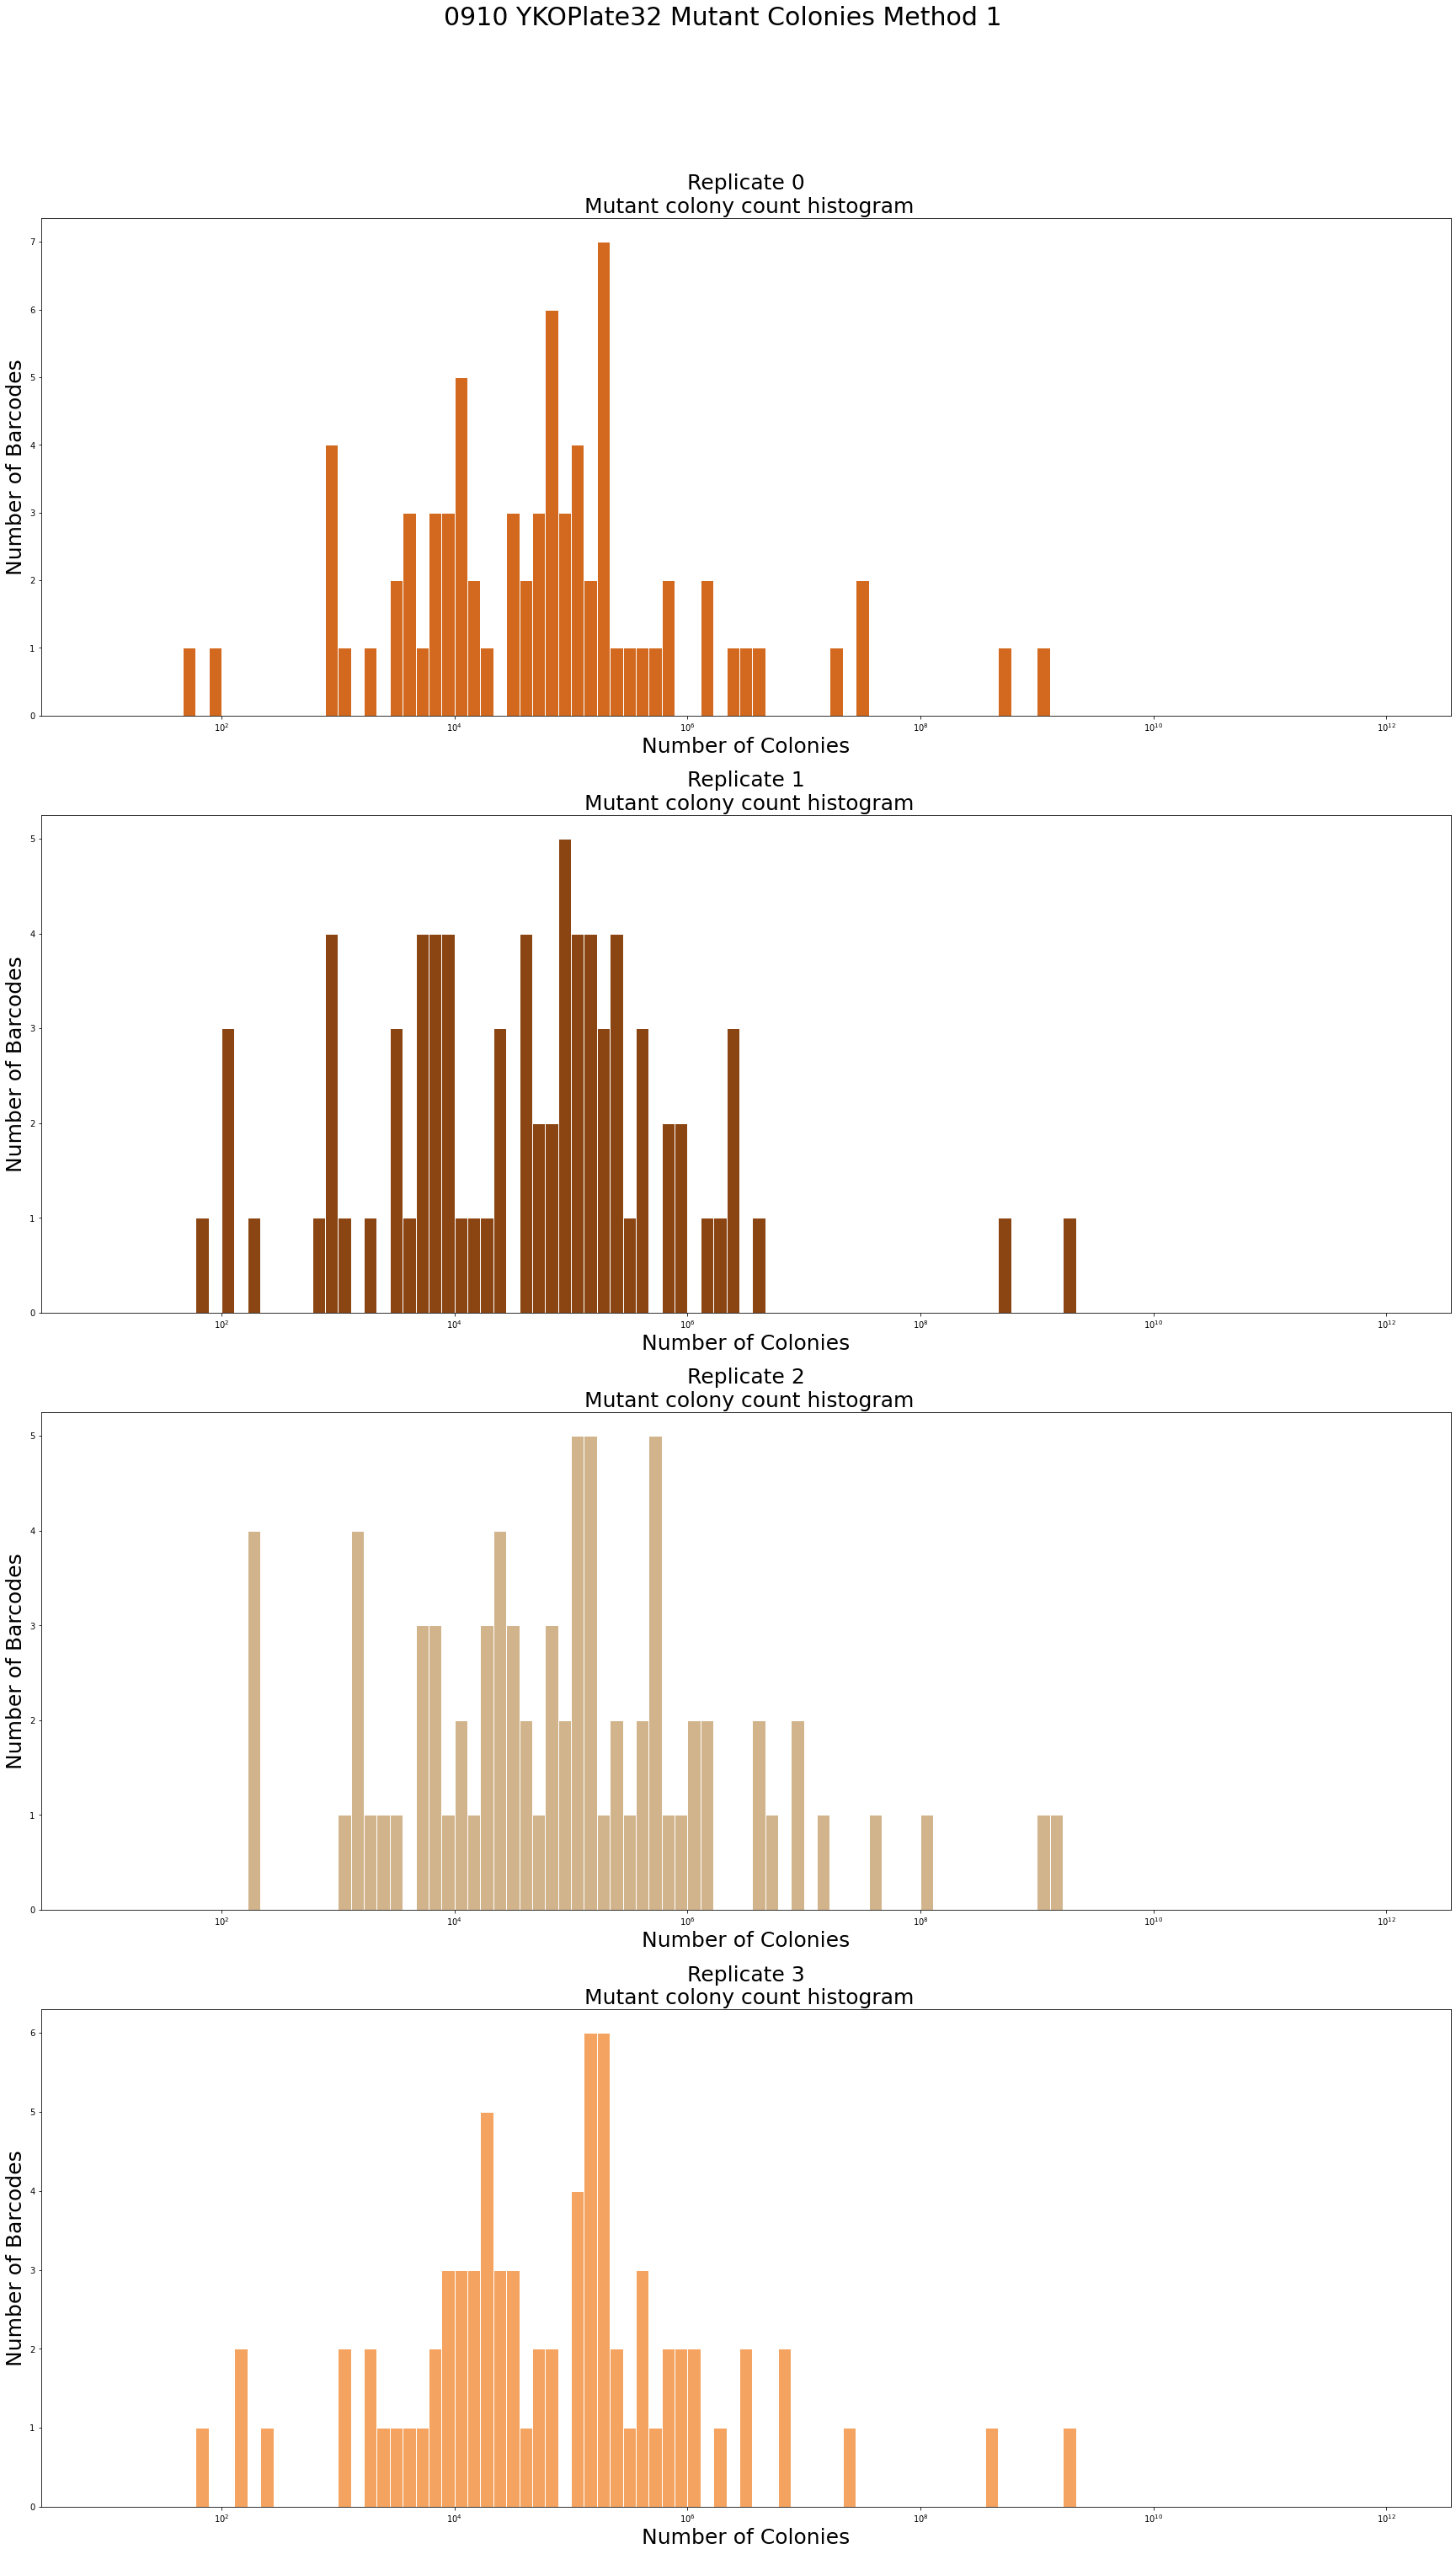

In [38]:
figure, ax = plt.subplots(NUM_REPLICATES,1,figsize=(30, 50))

for j in range(NUM_REPLICATES):
    ax[j].hist(num_colonies[j],  bins = np.logspace(1,12,100),ec='white', color=colors[j])
    ax[j].set_title(f'Replicate {j}\n Mutant colony count histogram', fontsize = 25)
    ax[j].set_ylabel('Number of Barcodes', fontsize = 25)
    ax[j].set_xlabel('Number of Colonies', fontsize = 25)
    ax[j].set_xscale('log')

figure.suptitle("0910 YKOPlate32 Mutant Colonies Method 1", fontsize=30, y = 0.95)
figure.savefig("0910 YKOPlate32 Mutant Colonies Method 1.pdf", format="pdf")
plt.show()


In [39]:
for j in range(NUM_REPLICATES):
    print(f'Total number of colonies in rep {j}: {np.sum(num_colonies[j])}')

Total number of colonies in rep 0: 1799999961
Total number of colonies in rep 1: 2299999955
Total number of colonies in rep 2: 2799999956
Total number of colonies in rep 3: 2499999962


### Method 1 w/o Can

For rep 0: 21 barcodes did not produce mutant colonies
For rep 1: 17 barcodes did not produce mutant colonies
For rep 2: 18 barcodes did not produce mutant colonies
For rep 3: 19 barcodes did not produce mutant colonies


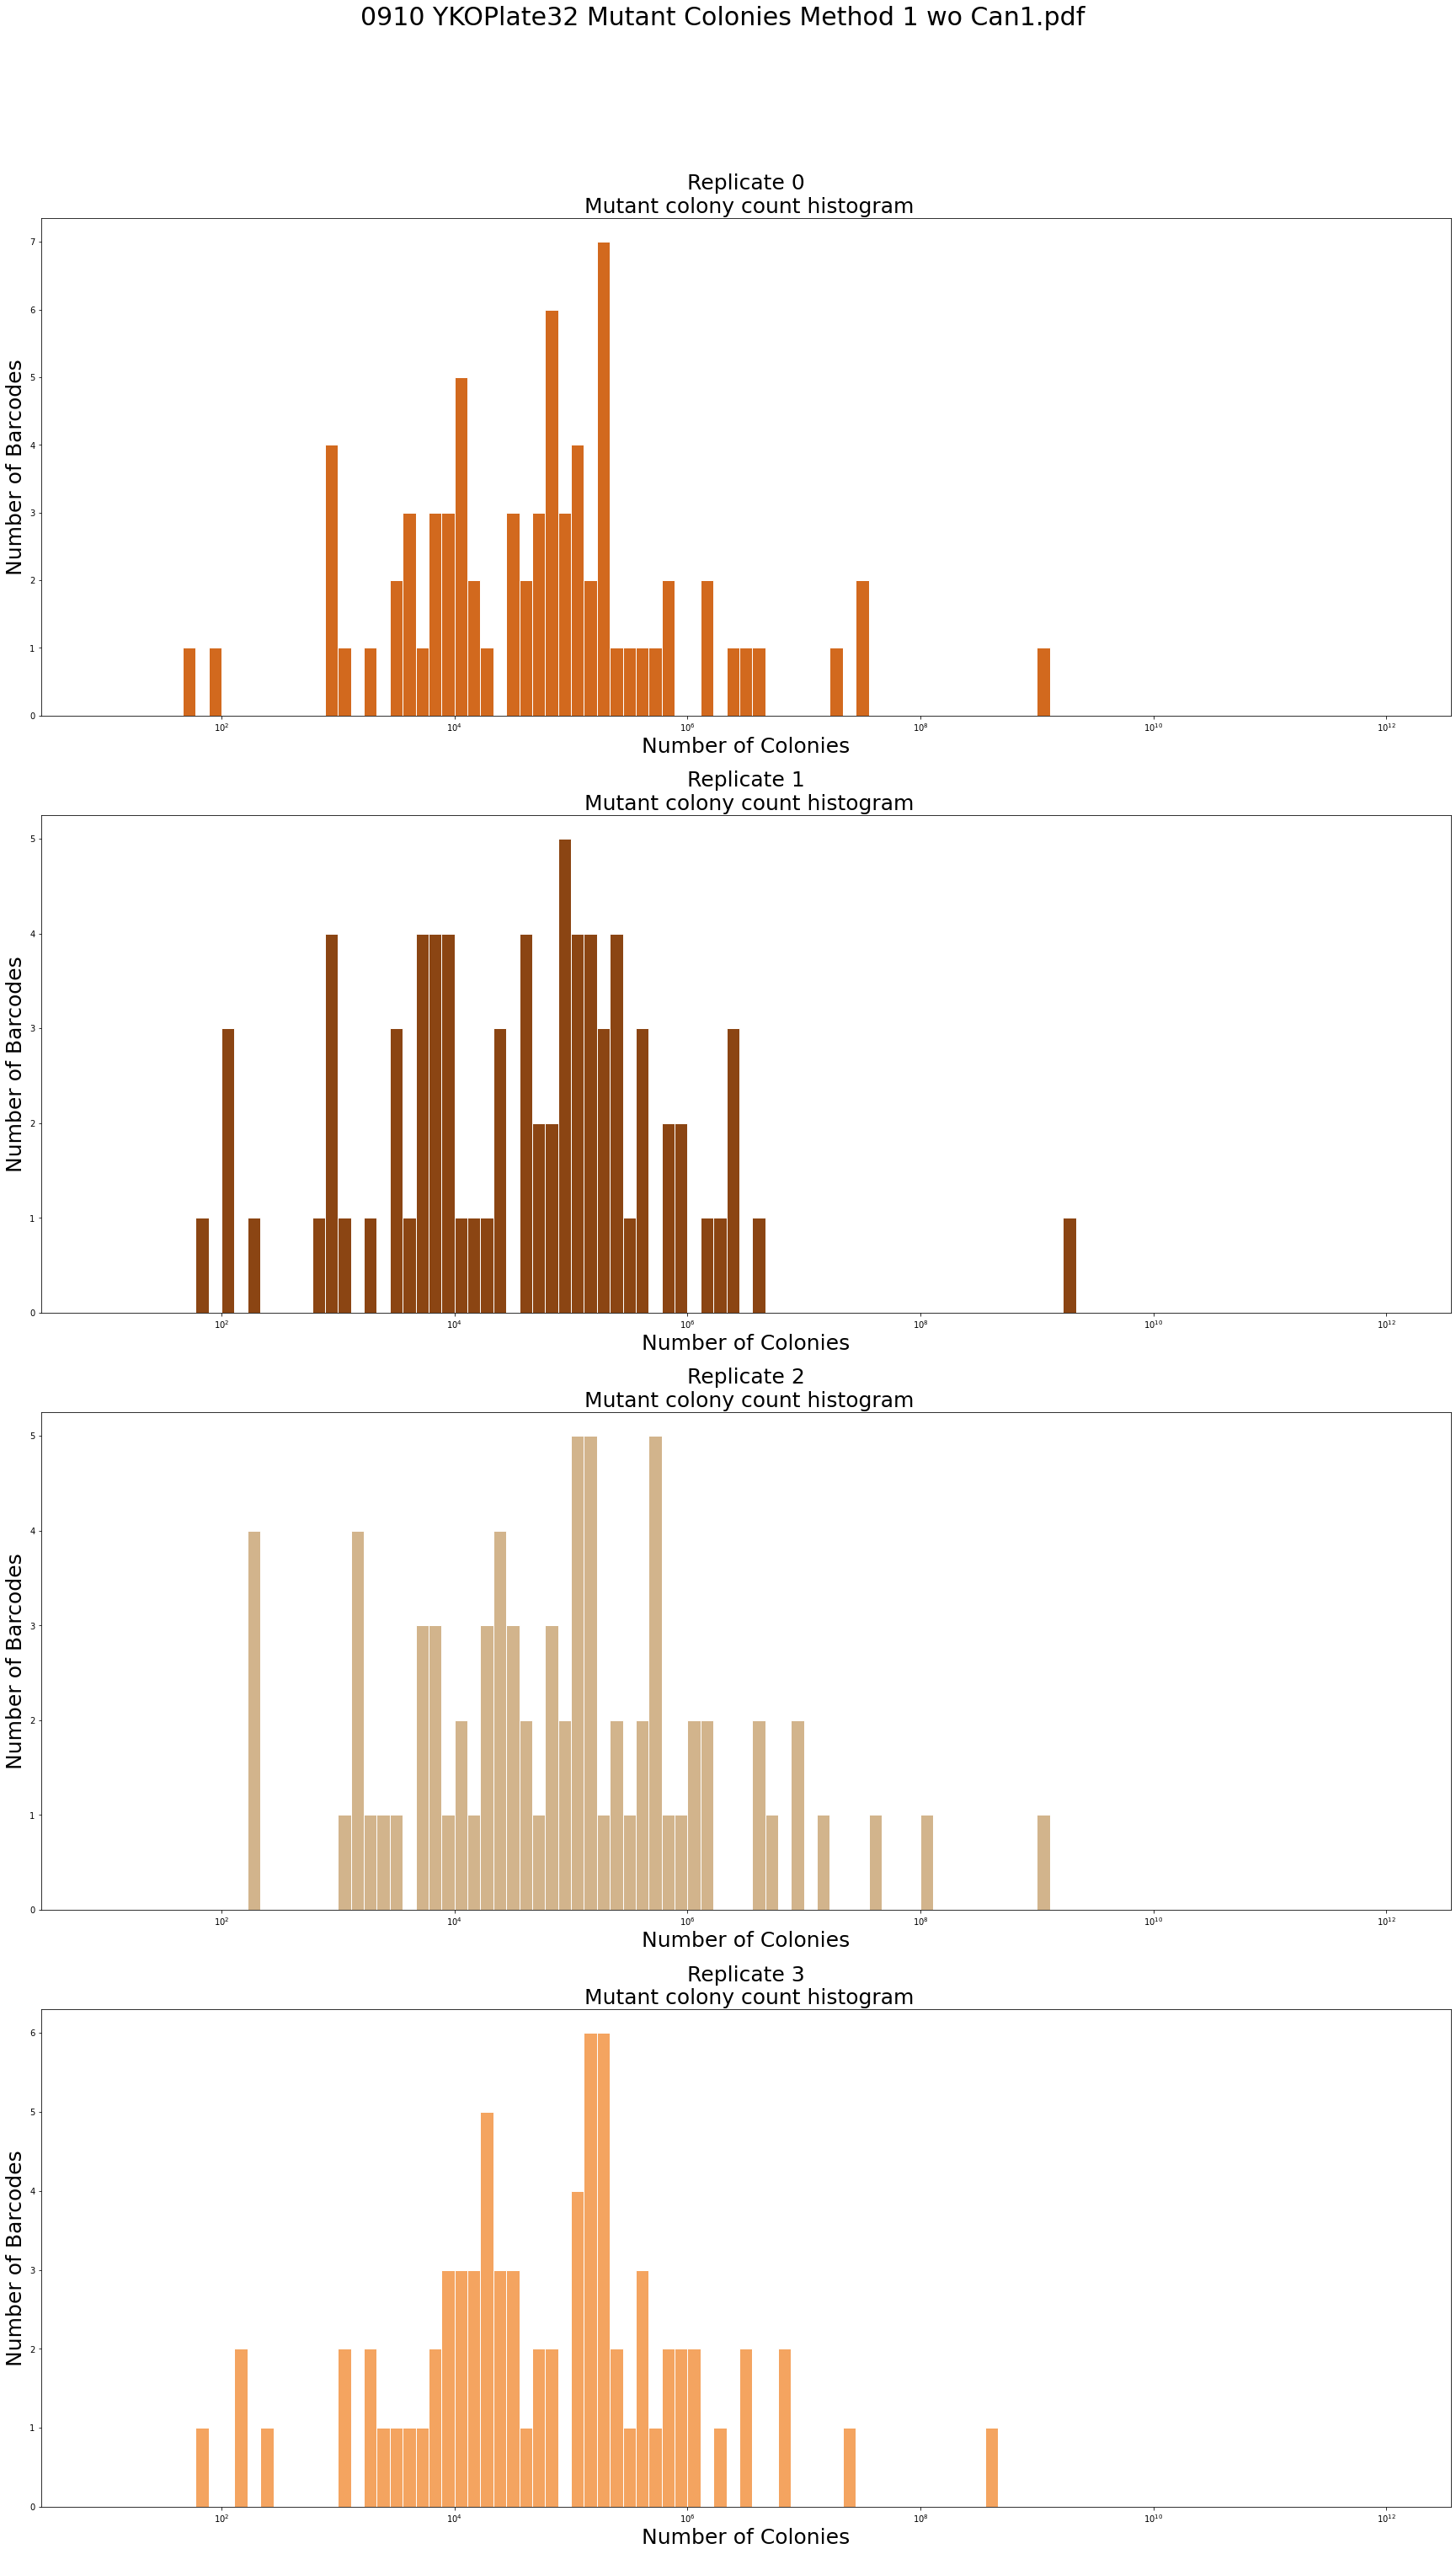

In [40]:
#since the canavanine spike in at loc 95, to exclude it, I just slice off the last element of the array
short_rep_fq = choose_rep_fq[:,:,:-1]

final_tp = short_rep_fq[:,T_FINAL]

s_num_colonies = np.array([final_tp[i]*TCAN_MUT[i] for i in range(NUM_REPLICATES)]).astype(int)

for j in range(NUM_REPLICATES):
    print(f'For rep {j}: {len(np.where(s_num_colonies[j] == 0)[0])} barcodes did not produce mutant colonies')

    
figure, ax = plt.subplots(NUM_REPLICATES,1,figsize=(30, 50))

for j in range(NUM_REPLICATES):
    ax[j].hist(s_num_colonies[j],  bins = np.logspace(1,12,100),ec='white', color=colors[j])
    ax[j].set_title(f'Replicate {j}\n Mutant colony count histogram', fontsize = 25)
    ax[j].set_ylabel('Number of Barcodes', fontsize = 25)
    ax[j].set_xlabel('Number of Colonies', fontsize = 25)
    ax[j].set_xscale('log')

figure.suptitle("0910 YKOPlate32 Mutant Colonies Method 1 wo Can1.pdf", fontsize=30, y = 0.95)
figure.savefig("0910 YKOPlate32 Mutant Colonies Method 1 wo Can1.pdf", format="pdf")
plt.show()



### Method 2
Obtain # of mutant colonies/bcd by calculating (reads of bcd/reads for can1) * 89000

In [41]:

choose_rep = np.array(choose_rep)

#selecting for reads at the final timepoint
choose_rep_counts = choose_rep[:,T_FINAL,want_counts,:] 

reads_by_can = np.zeros((NUM_REPLICATES, NUM_STRAINS)) 

#divide all barcode counts by canavanine counts then multiply by the spike in
for i in range(NUM_REPLICATES):
    
    reads_by_can[i] = choose_rep_counts[i] / choose_rep_counts[i,can1_location] * SPIKE

print(reads_by_can.shape) 

#round to nearest integer since colonies are counted in integer units
reads_by_can = np.array(reads_by_can).astype(int)


(4, 95)


In [42]:
reads_by_can[0][np.where(reads_by_can[0] != 0)]

array([     9,      5,     32,     28,   3131,     56,     66,     11,
          103,      3,      7,     17,     34,     16,     15,     36,
          116, 201848,      1,     24,      5,   5030,     11,     18,
           24,      7,     91,      1,      9,      1,     12,      2,
           12,      1,      1,      1,     35,      1,      1,     31,
         5051,     17,     33,    246,      1,     18,     39,      6,
          421,    262,      7,      2,      1,     14,      1,    580,
           10,    748,     12,  89000])

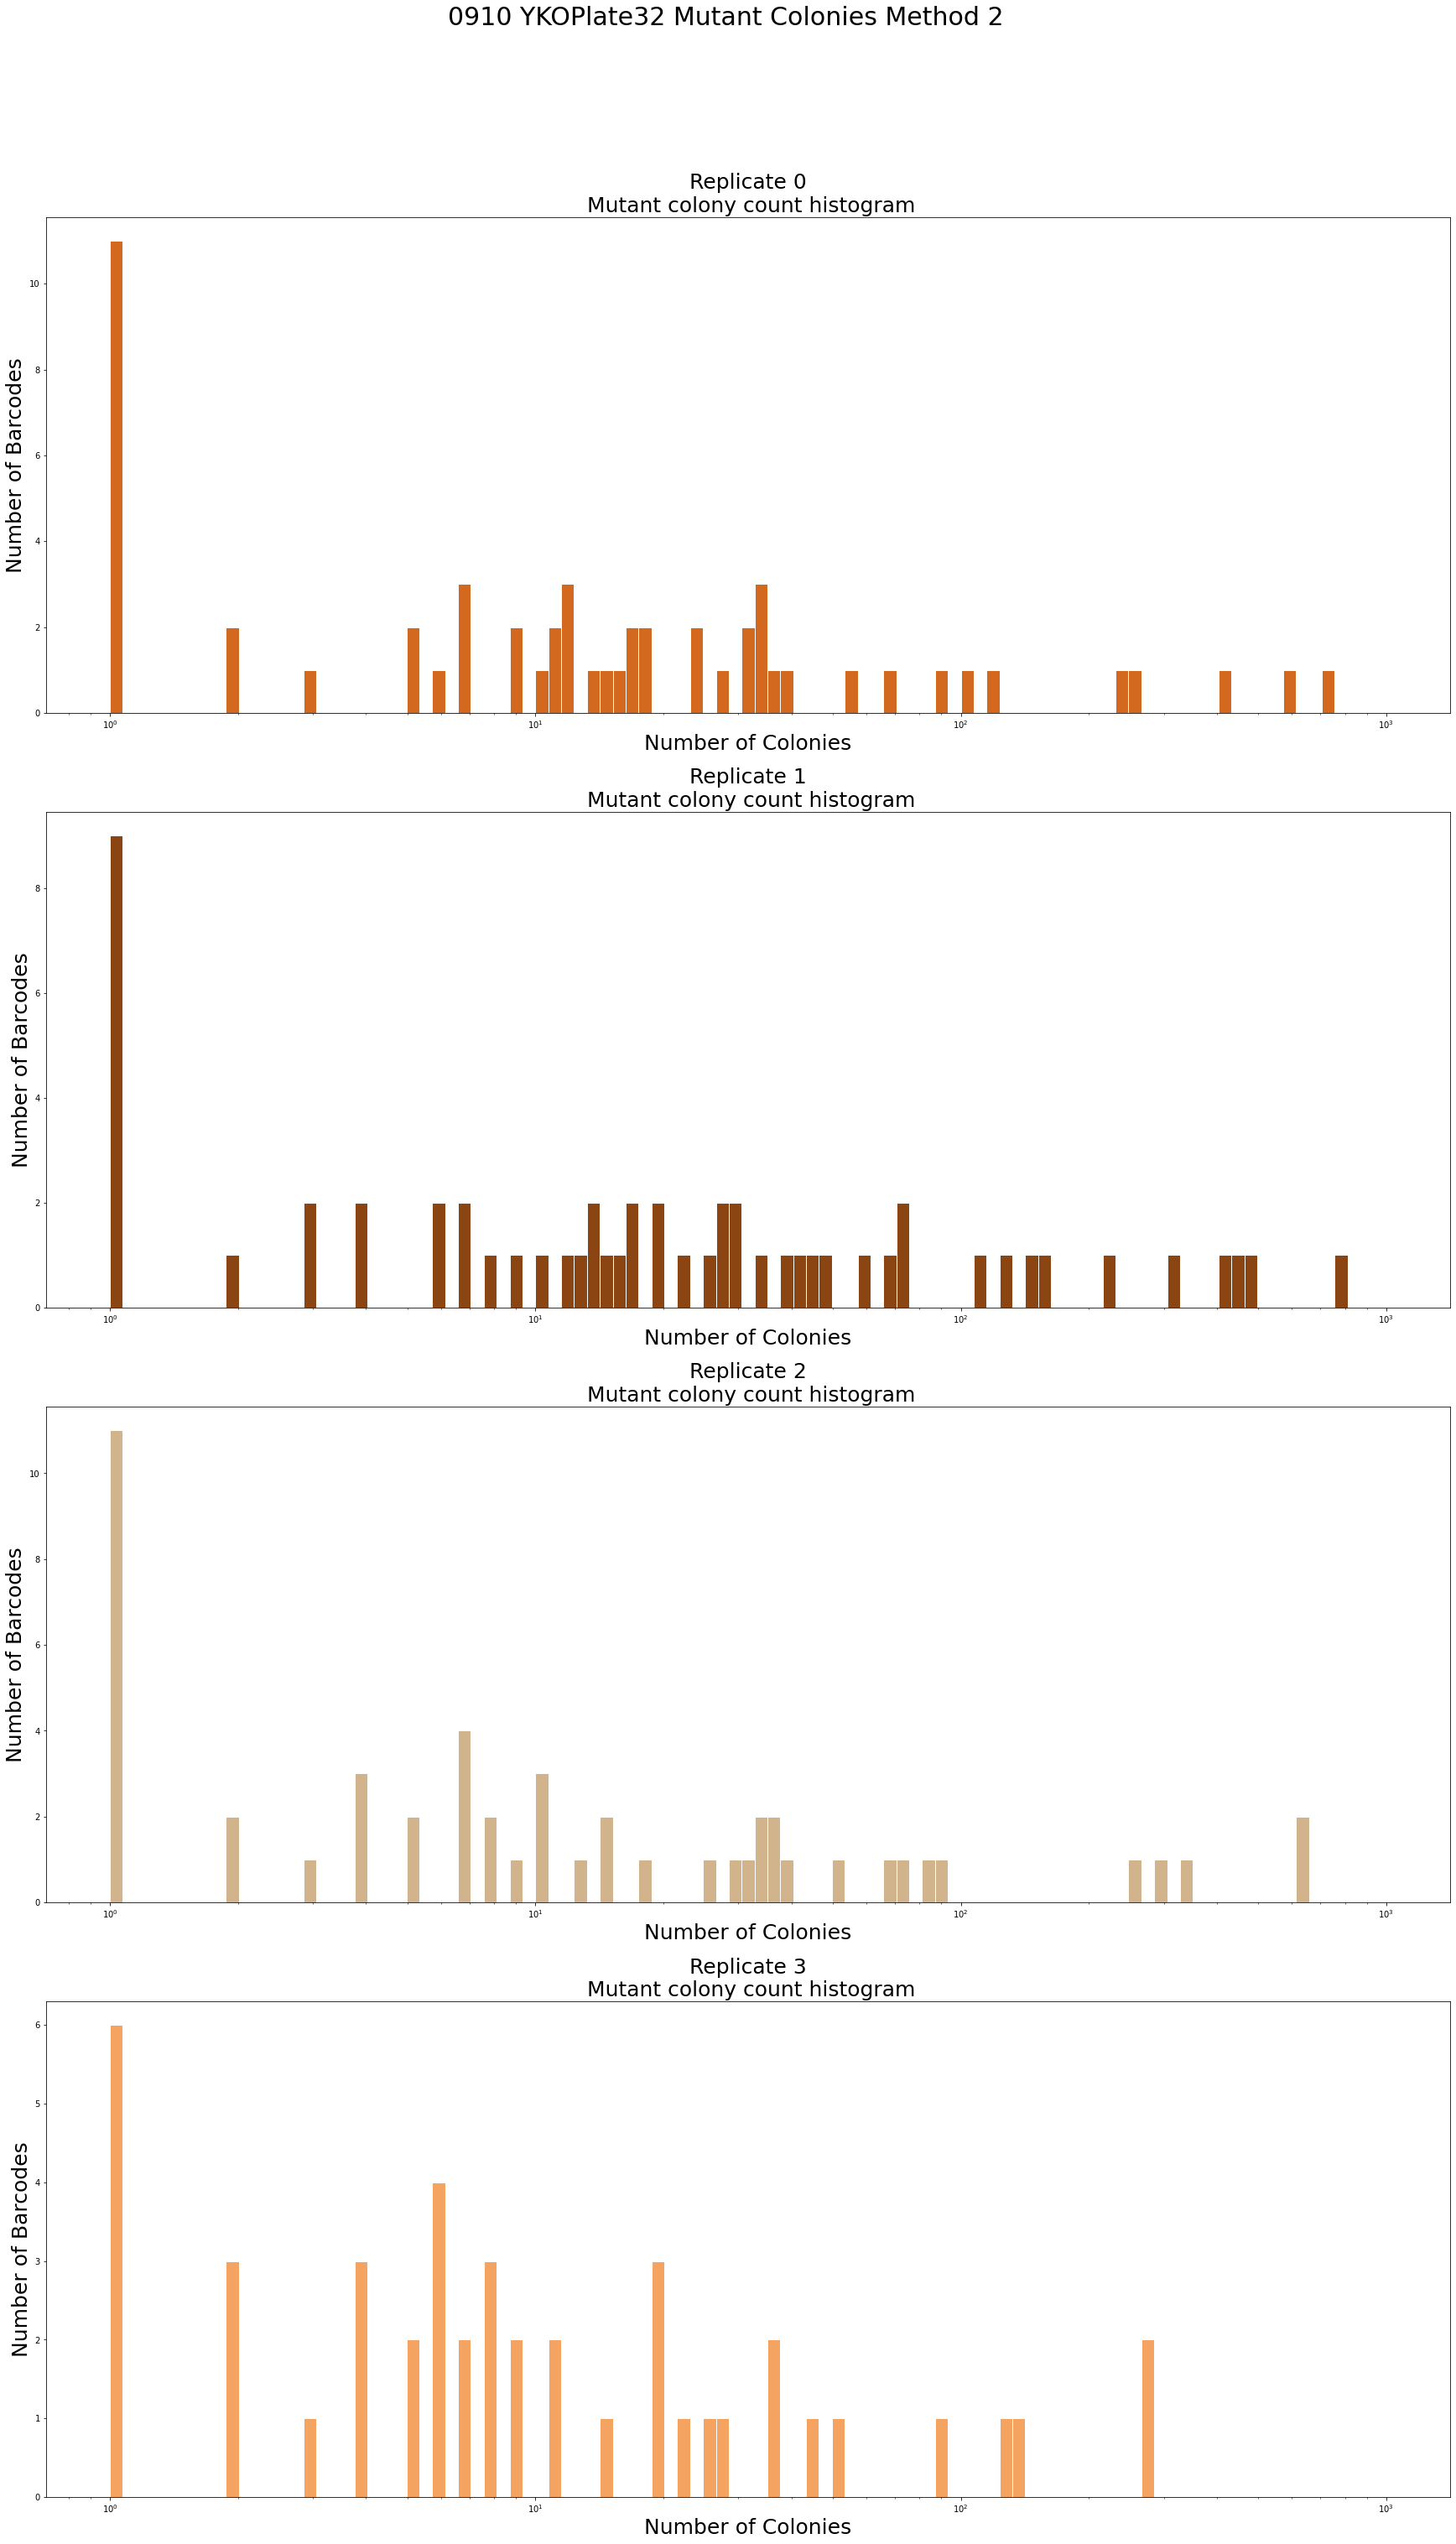

In [43]:
figure, ax = plt.subplots(NUM_REPLICATES,1,figsize=(30, 50))

for j in range(NUM_REPLICATES):
    ax[j].hist(reads_by_can[j], bins = np.logspace(0,3,100), ec='white', color=colors[j])
    #ax[j].hist(reads_by_can[j][np.where(reads_by_can[j] != 1)], bins = np.logspace(0,3,100), ec='white', color=colors[j])
    ax[j].set_title(f'Replicate {j}\n Mutant colony count histogram', fontsize = 25)
    ax[j].set_ylabel('Number of Barcodes', fontsize = 25)
    ax[j].set_xlabel('Number of Colonies', fontsize = 25)
    ax[j].set_xscale('log')

figure.suptitle("0910 YKOPlate32 Mutant Colonies Method 2", fontsize=30, y = 0.95)
figure.savefig("0910 YKOPlate32 Mutant Colonies Method 2.pdf", format="pdf")
plt.show()


In [44]:
for j in range(NUM_REPLICATES):
    print(f'Total number of colonies in rep {j}: {np.sum(reads_by_can[j])}')

Total number of colonies in rep 0: 307321
Total number of colonies in rep 1: 400236
Total number of colonies in rep 2: 181915
Total number of colonies in rep 3: 111949


### Method comparison

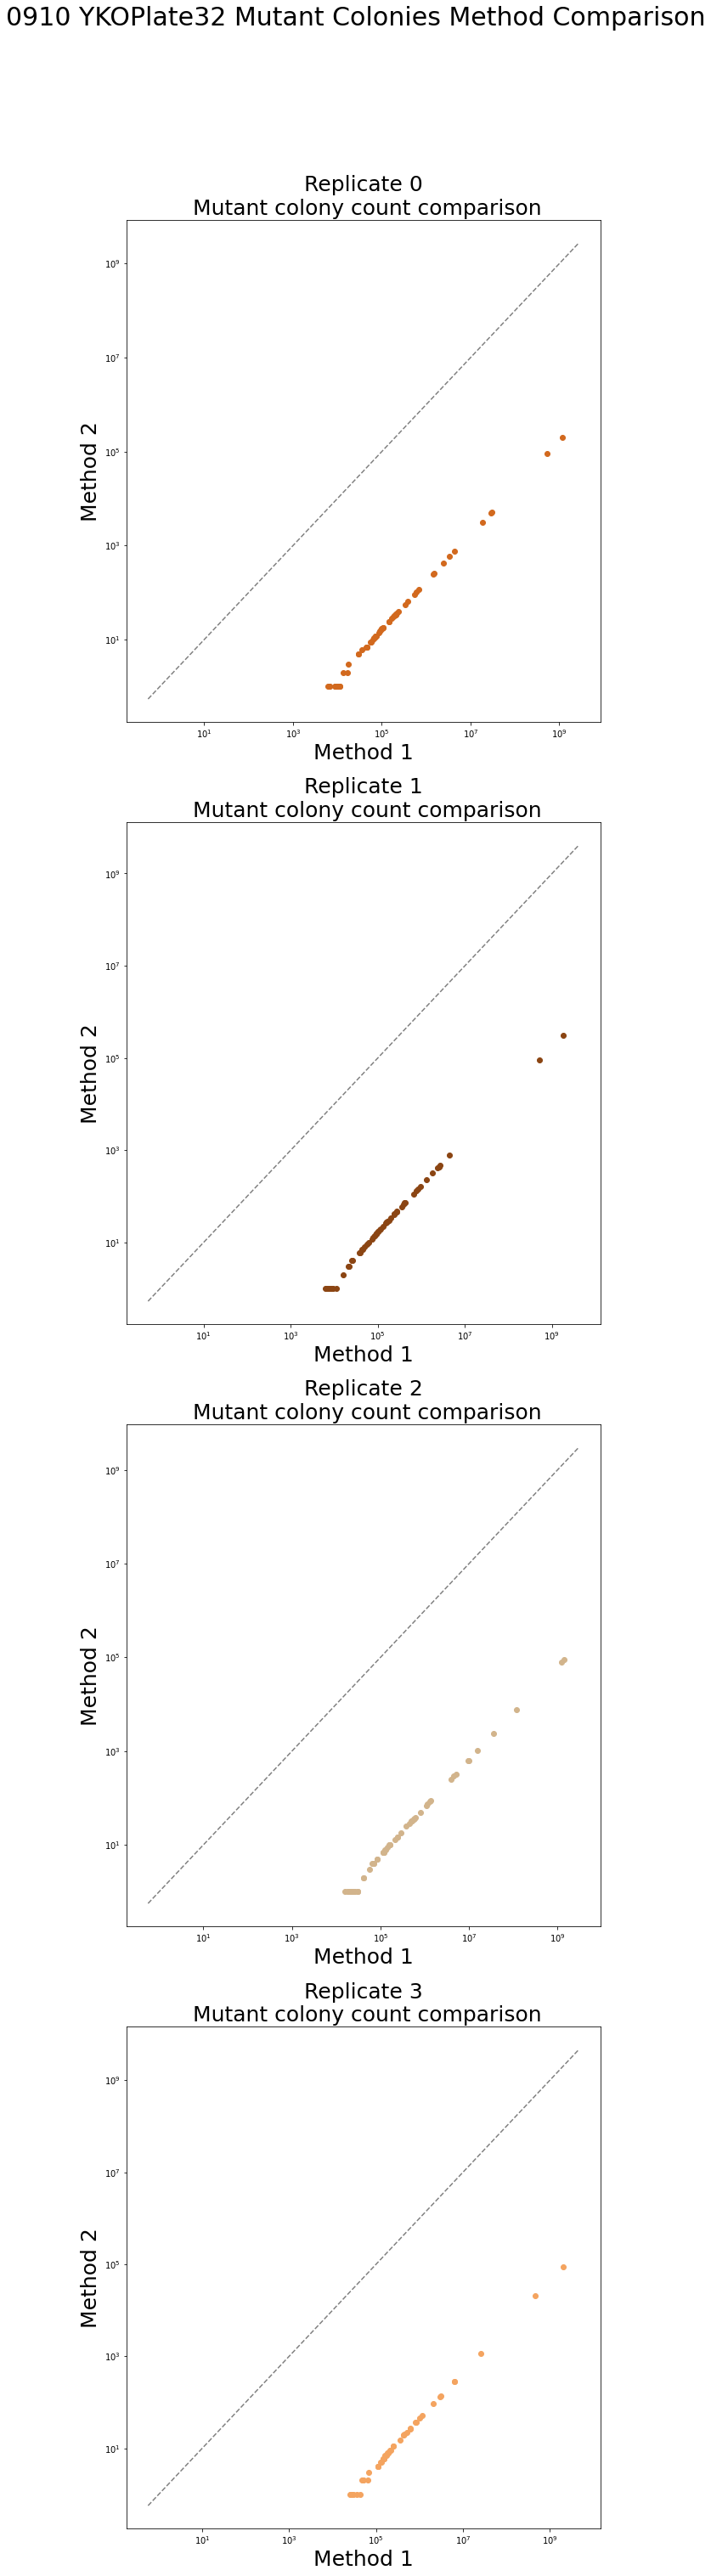

In [45]:
figure, ax = plt.subplots(NUM_REPLICATES,1,figsize=(10, 50))

for j in range(NUM_REPLICATES):
    ax[j].scatter(num_colonies[j], reads_by_can[j], c = colors[j])
    ax[j].set_title(f'Replicate {j}\n Mutant colony count comparison', fontsize = 25)
    ax[j].set_ylabel('Method 2', fontsize = 25)
    ax[j].set_xlabel('Method 1', fontsize = 25)
    ax[j].set_xscale('log')
    ax[j].set_yscale('log')
    
    xmin, xmax = ax[j].get_xlim()
    ymin, ymax = ax[j].get_ylim()
    limits = [min(xmin, ymin), max(xmax, ymax)]  

    ax[j].plot(limits, limits, linestyle="--", color="gray", label="Diagonal y=x")

    

figure.suptitle("0910 YKOPlate32 Mutant Colonies Method Comparison", fontsize=30, y = 0.95)
figure.savefig("0910 YKOPlate32 Mutant Colonies Method Comparison.pdf", format="pdf")

plt.show()

In [46]:
print('Method 1\n')
for i in range(NUM_REPLICATES):
    print(f'  Rep {i} # of mutants: {np.size(np.where(num_colonies[i] != 0))}')
    
print('\nMethod 2\n')
for i in range(NUM_REPLICATES):
    print(f'  Rep {i} # of mutants: {np.size(np.where(reads_by_can[i] != 0))}')
    


Method 1

  Rep 0 # of mutants: 74
  Rep 1 # of mutants: 78
  Rep 2 # of mutants: 77
  Rep 3 # of mutants: 76

Method 2

  Rep 0 # of mutants: 60
  Rep 1 # of mutants: 58
  Rep 2 # of mutants: 56
  Rep 3 # of mutants: 47


## 4. Make an excel sheet containing the colony sizes of each barcode in each replicate for both methods

a. Find the barcode frequenies at a given timepoint, multiply by the total population
b. Find the barcode frequences after canavanine, use the can 1 spike in the find the colony count. Multiply frequencies by the totatl colony count.


a. Find the barcode frequenies at a given timepoint, multiply by the total population

In [47]:
#num_colonies

b. Find the colony count for each barcode according to the canavanine spike in

In [48]:
#reads_by_can 

c. export to an excel file

In [49]:
headers = [nm_bcds[i][0] for i in range(NUM_STRAINS)]

df_m1 = pd.DataFrame((num_colonies).astype(int), columns=headers)
df_m2 = pd.DataFrame(reads_by_can, columns=headers)

with pd.ExcelWriter("bcd_colony_counts.xlsx", engine='openpyxl') as writer:
    df_m1.to_excel(writer, sheet_name="Method 1", index=False)
    df_m2.to_excel(writer, sheet_name="Method 2", index=False)

## 5.  Make an excel doc showing reads for each barcode replicate and timepoint

In [50]:
  
with pd.ExcelWriter("bcd_reads.xlsx", engine='openpyxl') as writer:
    for t in range(NUM_TIMEPOINTS):
        df = pd.DataFrame(choose_rep[:, :, want_counts, :][:, t], columns=headers)
        df.to_excel(writer, sheet_name=f"Time {t}", index=False)


## 6. CALCULATE MUTATION RATES

Maximum likelihood method 
*note that there are not enough replicates of each strain to have an acccurate measurement of mutation rate

1. Start with a trial mutant number, m
2. Calculate (r)/m - ln(m) - 1.24 = 0 where (r) is the median # of mutants
3. Find the probabilies: c_r = (# of cultures that had r mutants) and p_r = (# cultures that had r mutants) / (total # of cultures)
3. Find the product of the probabilities p_r^c_r whehere p_r is the probability of having r mutant colonies and c_r is the number of flasks that has that number of colonies
4. Multiply those probabilites together
5. Find the m that maximizes this product of probabilites
6. mu = m/(population size)



In [73]:
def m_solver(median, pop_size):
    def equation(m):
        return median/m - np.log(m) - 1.24
    
    # Initial guess - you can tune this based on your data
    initial_guess = median / 2.0  # or whatever works well for your problem
    
    m_solution = fsolve(equation, initial_guess)[0]
    mu = m_solution / pop_size
    return mu


In [74]:
#for each barcode, calculate r median values and find populations
medians = [np.median(reads_by_can[:,i]) for i in range(NUM_STRAINS)]
freq_t = choose_rep_fq[:,1]
populations = np.array([freq_t[i]*TCAN_TOTAL[i] for i in range(NUM_REPLICATES)]).astype(int)
avg_pops = [np.average(populations[:,i]) for i in range(NUM_STRAINS)]

In [75]:

# Vectorized version
mus = np.array([m_solver(medians[i], avg_pops[i]) for i in range(NUM_STRAINS)])
mus

/var/folders/7c/76dj47x13vqcyb9yzh27f6s40000gn/T/ipykernel_32900/3476641821.py:3: RuntimeWarning: invalid value encountered in divide
  return median/m - np.log(m) - 1.24
/var/folders/7c/76dj47x13vqcyb9yzh27f6s40000gn/T/ipykernel_32900/3476641821.py:3: RuntimeWarning: divide by zero encountered in log
  return median/m - np.log(m) - 1.24
/var/folders/7c/76dj47x13vqcyb9yzh27f6s40000gn/T/ipykernel_32900/3476641821.py:8: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  m_solution = fsolve(equation, initial_guess)[0]
/var/folders/7c/76dj47x13vqcyb9yzh27f6s40000gn/T/ipykernel_32900/3476641821.py:9: RuntimeWarning: invalid value encountered in double_scalars
  mu = m_solution / pop_size
/var/folders/7c/76dj47x13vqcyb9yzh27f6s40000gn/T/ipykernel_32900/3476641821.py:3: RuntimeWarning: invalid value encountered in log
  return median/m - np.log(m) - 1.24


array([9.73011208e-06, 0.00000000e+00, 4.99030041e-06, 7.26507011e-06,
                  nan, 0.00000000e+00, 5.94710441e-06, 9.31724667e-05,
                  nan, 6.36556354e-06,            nan, 8.51436691e-06,
       0.00000000e+00, 0.00000000e+00, 8.40437209e-06, 4.80295422e-06,
       5.00591859e-06, 6.32352582e-06,            nan, 7.73805175e-06,
       3.40094786e-06,            nan, 9.04831389e-06, 5.74742460e-06,
       1.36920735e-05, 2.10988534e-05, 2.78171127e-05, 0.00000000e+00,
       5.20784127e-06, 6.70086784e-06, 1.80478222e-05, 0.00000000e+00,
       0.00000000e+00, 3.62101361e-06, 4.62087173e-06, 1.17830406e-05,
       6.33901104e-06, 0.00000000e+00, 6.82520460e-05, 4.57135306e-06,
       1.40628449e-06, 0.00000000e+00,            nan, 0.00000000e+00,
       3.19294224e-06, 1.44147774e-05, 7.95241350e-06, 0.00000000e+00,
       4.62387798e-06,            nan, 5.34566310e-06,            nan,
       4.88901084e-06, 8.24424272e-06, 0.00000000e+00, 0.00000000e+00,
      

In [76]:
"""
There are not enough replicates to resolve mutation rate. However, this is the method i want to use

"""

'\nThere are not enough replicates to resolve mutation rate. However, this is the method i want to use\n\n'